## 1. Install dependencies

Run this cell first in Google Colab, SageMaker Studio, or Jupyter.


In [1]:
# Final project dependencies for SageMaker Studio / Jupyter.
# Run this once before the rest of the notebook. If your kernel already has newer versions,
# this may ask for a kernel restart; restart once, then Run All.
%pip install -q --upgrade pip
%pip install pandas requests tqdm python-dateutil rapidfuzz pyyaml scipy matplotlib joblib boto3 sagemaker shap xgboost "scikit-learn==1.4.2"


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.

## 2. Imports and configuration

In [2]:
import os
import re
import json
import time
import warnings
from pathlib import Path
from datetime import datetime, timezone

import requests
import pandas as pd
from tqdm.auto import tqdm
from dateutil import parser as dateparser

try:
    from rapidfuzz import fuzz, process
except ImportError:
    fuzz = None
    process = None
    print("rapidfuzz not installed. Name-similarity features will be skipped.")

warnings.filterwarnings("ignore")

BASE_DIR = Path("supply_chain_risk_dataset")
RAW_DIR = BASE_DIR / "raw"
PROCESSED_DIR = BASE_DIR / "processed"
DEPLOY_DIR = Path("sagemaker_deploy")

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

MAX_BENIGN_PACKAGES = 25_000
MAX_PACKAGES_TO_ENRICH = 22_000
MIN_EXPECTED_PER_CLASS = 10_000

# PyPI API throttle. Increase to 0.10-0.15 if you see rate-limit issues.
REQUEST_SLEEP_SECONDS = 0.05

# If True, ignore any cached metadata and re-fetch all package metadata.
# In this final-run notebook, False means "use cache only if it is large enough."
FORCE_REFETCH = False

# AWS/SageMaker settings
S3_BUCKET = ""  # leave blank to use SageMaker default bucket
S3_DATA_PREFIX = "supply-chain-risk"
S3_MODEL_PREFIX = "supply-chain-risk/models"
SKLEARN_VERSION = "1.4-2"
INSTANCE_TYPE = "ml.m5.large"

# Timestamped endpoint names prevent Run All from failing because of old endpoint names.
ENDPOINT_NAME = f"supply-chain-risk-endpoint-{datetime.now().strftime('%Y%m%d-%H%M%S')}"

# Keep False until after your video. Set True and rerun the cleanup cell at the end to delete.
AUTO_DELETE_ENDPOINT_AFTER_TEST = False

TODAY = datetime.now(timezone.utc)

print("Data directory:", BASE_DIR.resolve())
print("Endpoint name for this run:", ENDPOINT_NAME)


Data directory: /home/sagemaker-user/final-project/supply_chain_risk_dataset
Endpoint name for this run: supply-chain-risk-endpoint-20260615-061841


## 3. Helper functions

In [3]:
def safe_get_json(url, params=None, headers=None, timeout=60, quiet_404=False):
    """GET a URL and return JSON, or None on failure."""
    try:
        response = requests.get(url, params=params, headers=headers, timeout=timeout)
        if response.status_code == 200:
            return response.json()
        if response.status_code == 404 and quiet_404:
            return None
        print(f"Request failed: {response.status_code} | {url}")
        return None
    except Exception as e:
        print(f"Request error for {url}: {e}")
        return None


def normalize_package_name(name):
    """
    Normalize package names for deduplication.
    PEP 503 style normalization: lowercase and collapse -, _, . into -
    """
    if not isinstance(name, str):
        return None
    name = name.strip().lower()
    name = re.sub(r"[-_.]+", "-", name)
    return name if name else None


def save_csv(df, filename):
    path = PROCESSED_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved {len(df):,} rows -> {path}")
    return path


def save_json(data, filename):
    path = RAW_DIR / filename
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)
    print(f"Saved JSON -> {path}")
    return path


# Part A — Create malicious labels

We will create `label = 1` rows from public malicious-package datasets.

Sources included in this notebook:

1. DataDog malicious software packages dataset
2. OpenSSF malicious-packages OSV repository
3. pypi_malregistry GitHub repository

The notebook tries to parse package names safely from metadata files or repository paths.


## 4. DataDog malicious software packages dataset

DataDog's repository includes `manifest.json` files for ecosystems such as PyPI and npm. The manifest tells whether a package/version is considered malicious or compromised.


In [4]:
def load_datadog_manifest(ecosystem="pypi"):
    """
    Load DataDog manifest.json for a specific ecosystem.
    Common ecosystem values: pypi, npm
    """
    urls_to_try = [
        f"https://raw.githubusercontent.com/DataDog/malicious-software-packages-dataset/main/samples/{ecosystem}/manifest.json",
        f"https://raw.githubusercontent.com/DataDog/malicious-software-packages-dataset/master/samples/{ecosystem}/manifest.json",
    ]

    for url in urls_to_try:
        data = safe_get_json(url)
        if data is not None:
            print(f"Loaded DataDog manifest for {ecosystem}: {len(data):,} entries")
            save_json(data, f"datadog_{ecosystem}_manifest.json")
            return data

    print(f"Could not load DataDog manifest for {ecosystem}")
    return {}


def datadog_manifest_to_df(manifest, ecosystem):
    rows = []
    for package_name, affected_versions in manifest.items():
        normalized = normalize_package_name(package_name)
        if not normalized:
            continue

        if affected_versions is None:
            malicious_type = "malicious_intent"
            versions = []
        elif isinstance(affected_versions, list):
            malicious_type = "compromised_versions"
            versions = affected_versions
        else:
            malicious_type = "unknown"
            versions = []

        rows.append({
            "package_name": package_name,
            "normalized_name": normalized,
            "ecosystem": ecosystem,
            "label": 1,
            "label_source": "datadog_malicious_software_packages_dataset",
            "malicious_type": malicious_type,
            "affected_versions": json.dumps(versions)
        })

    return pd.DataFrame(rows)


datadog_pypi_manifest = load_datadog_manifest("pypi")
datadog_npm_manifest = load_datadog_manifest("npm")

datadog_pypi_df = datadog_manifest_to_df(datadog_pypi_manifest, "pypi")
datadog_npm_df = datadog_manifest_to_df(datadog_npm_manifest, "npm")

datadog_malicious_df = pd.concat([datadog_pypi_df, datadog_npm_df], ignore_index=True)
datadog_malicious_df.head()


Loaded DataDog manifest for pypi: 1,826 entries
Saved JSON -> supply_chain_risk_dataset/raw/datadog_pypi_manifest.json
Loaded DataDog manifest for npm: 45,420 entries
Saved JSON -> supply_chain_risk_dataset/raw/datadog_npm_manifest.json


,package_name,normalized_name,ecosystem,label,label_source,malicious_type,affected_versions
0,0wneg,0wneg,pypi,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
1,1337test,1337test,pypi,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
2,282828282828282828,282828282828282828,pypi,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
3,EZBEAMER,ezbeamer,pypi,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
4,EZBEAMSW,ezbeamsw,pypi,1,datadog_malicious_software_packages_dataset,malicious_intent,[]


## 5. OpenSSF malicious-packages repository

OpenSSF stores reports in OSV format. To avoid cloning the whole repo manually, this notebook uses GitHub's repository tree API to discover OSV JSON files and parse affected package names.


In [5]:
def github_tree(owner, repo, branch="main"):
    """
    Fetch recursive GitHub repo tree.
    Does not require a token for small usage, but may hit rate limits.
    """
    url = f"https://api.github.com/repos/{owner}/{repo}/git/trees/{branch}?recursive=1"
    data = safe_get_json(url)
    if data is None:
        return []
    return data.get("tree", [])


def load_raw_github_file(owner, repo, branch, path):
    url = f"https://raw.githubusercontent.com/{owner}/{repo}/{branch}/{path}"
    return safe_get_json(url)


def parse_osv_package_records(osv_json, label_source):
    """
    Extract package/ecosystem records from an OSV JSON object.
    """
    rows = []

    affected = osv_json.get("affected", [])
    aliases = osv_json.get("aliases", [])
    osv_id = osv_json.get("id")
    summary = osv_json.get("summary") or osv_json.get("details", "")[:200]

    for item in affected:
        pkg = item.get("package", {}) or {}
        package_name = pkg.get("name")
        ecosystem = pkg.get("ecosystem")

        if not package_name:
            continue

        rows.append({
            "package_name": package_name,
            "normalized_name": normalize_package_name(package_name),
            "ecosystem": ecosystem.lower() if isinstance(ecosystem, str) else None,
            "label": 1,
            "label_source": label_source,
            "malicious_type": "osv_malicious_report",
            "affected_versions": json.dumps(item.get("versions", [])),
            "osv_id": osv_id,
            "aliases": json.dumps(aliases),
            "summary": summary
        })

    return rows


def collect_openssf_malicious_packages(max_files=3000):
    cache_path = PROCESSED_DIR / "openssf_malicious_packages.csv"

    if cache_path.exists():
        df = pd.read_csv(cache_path)
        print(f"Loaded OpenSSF malicious packages from cache: {len(df):,} rows")
        return df

    tree = github_tree("ossf", "malicious-packages", "main")
    print(f"OpenSSF tree entries: {len(tree):,}")

    json_paths = [
        item["path"]
        for item in tree
        if item.get("type") == "blob"
        and item.get("path", "").startswith("osv/")
        and item.get("path", "").endswith(".json")
        and "/withdrawn/" not in item.get("path", "")
    ]

    print(f"OpenSSF OSV JSON files discovered: {len(json_paths):,}")

    rows = []
    for path in tqdm(json_paths[:max_files], desc="Parsing OpenSSF OSV files"):
        osv = load_raw_github_file("ossf", "malicious-packages", "main", path)
        if osv:
            rows.extend(parse_osv_package_records(osv, "openssf_malicious_packages"))
        time.sleep(0.02)

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.drop_duplicates(subset=["normalized_name", "ecosystem", "osv_id"])

    print(f"OpenSSF malicious package rows: {len(df):,}")
    save_csv(df, "openssf_malicious_packages.csv")
    return df


openssf_malicious_df = collect_openssf_malicious_packages(max_files=3000)
openssf_malicious_df.head()


Loaded OpenSSF malicious packages from cache: 2,999 rows


,package_name,normalized_name,ecosystem,label,label_source,malicious_type,affected_versions,osv_id,aliases,summary
0,amzn-codewhisperer-streaming-client,amzn-codewhisperer-streaming-client,crates.io,1,openssf_malicious_packages,osv_malicious_report,"[""99.0.1""]",MAL-2026-3103,[],Malicious code in amzn_codewhisperer_streaming...
1,amzn-consolas-client,amzn-consolas-client,crates.io,1,openssf_malicious_packages,osv_malicious_report,"[""99.0.1""]",MAL-2026-3101,[],Malicious code in amzn_consolas_client (crates...
2,littest,littest,crates.io,1,openssf_malicious_packages,osv_malicious_report,"[""0.3.1""]",MAL-2023-8429,[],Malicious code in littest (crates.io)
3,lsh,lsh,crates.io,1,openssf_malicious_packages,osv_malicious_report,"[""99.0.1"", ""99.1.0""]",MAL-2026-3126,[],Malicious code in lsh (crates.io)
4,mysten-metrics,mysten-metrics,crates.io,1,openssf_malicious_packages,osv_malicious_report,"[""9.0.3""]",MAL-2026-2958,[],Malicious code in mysten_metrics (crates.io)


## 6. pypi_malregistry

This repo is PyPI-specific. It stores malicious package source archives in a structure like:

`package name -> version -> source code zip file`

We will parse package names from repository paths using GitHub's tree API. We will **not download or run malicious code**.


In [6]:
def collect_pypi_malregistry_labels(max_paths=20000):
    tree = github_tree("lxyeternal", "pypi_malregistry", "main")
    print(f"pypi_malregistry tree entries: {len(tree):,}")

    rows = []
    archive_exts = (".zip", ".tar.gz", ".tgz", ".whl", ".tar.bz2")

    for item in tree[:max_paths]:
        path = item.get("path", "")
        if item.get("type") != "blob":
            continue
        if not path.lower().endswith(archive_exts):
            continue

        parts = path.split("/")
        if len(parts) >= 2:
            package_name = parts[0]
        else:
            continue

        normalized = normalize_package_name(package_name)
        if not normalized:
            continue

        version = parts[1] if len(parts) >= 3 else None

        rows.append({
            "package_name": package_name,
            "normalized_name": normalized,
            "ecosystem": "pypi",
            "label": 1,
            "label_source": "pypi_malregistry",
            "malicious_type": "malicious_pypi_package",
            "affected_versions": json.dumps([version] if version else []),
            "repo_path": path
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.drop_duplicates(subset=["normalized_name", "ecosystem"])
    print(f"pypi_malregistry malicious package rows: {len(df):,}")
    return df


pypi_malregistry_df = collect_pypi_malregistry_labels()
pypi_malregistry_df.head()


pypi_malregistry tree entries: 33,631
pypi_malregistry malicious package rows: 5,939


,package_name,normalized_name,ecosystem,label,label_source,malicious_type,affected_versions,repo_path
0,0x000testqwe,0x000testqwe,pypi,1,pypi_malregistry,malicious_pypi_package,"[""5.20.4""]",0x000testqwe/5.20.4/0x000testqwe-5.20.4.tar.gz
1,10Cent10,10cent10,pypi,1,pypi_malregistry,malicious_pypi_package,"[""999.0.4""]",10Cent10/999.0.4/10Cent10-999.0.4.tar.gz
2,10Cent11,10cent11,pypi,1,pypi_malregistry,malicious_pypi_package,"[""999.0.4""]",10Cent11/999.0.4/10Cent11-999.0.4.tar.gz
3,11cent,11cent,pypi,1,pypi_malregistry,malicious_pypi_package,"[""999.0.0""]",11cent/999.0.0/11Cent-999.0.0.tar.gz
8,123bla,123bla,pypi,1,pypi_malregistry,malicious_pypi_package,"[""0.0.1""]",123bla/0.0.1/123bla-0.0.1-py3-none-any.whl


## 7. Combine malicious labels

In [7]:
malicious_dfs = [
    datadog_malicious_df,
    openssf_malicious_df,
    pypi_malregistry_df
]

malicious_labels_df = pd.concat(
    [df for df in malicious_dfs if df is not None and not df.empty],
    ignore_index=True,
    sort=False
)

if not malicious_labels_df.empty:
    malicious_labels_df["normalized_name"] = malicious_labels_df["package_name"].apply(normalize_package_name)
    malicious_labels_df["ecosystem"] = malicious_labels_df["ecosystem"].fillna("unknown").astype(str).str.lower()

    malicious_labels_df = (
        malicious_labels_df
        .groupby(["normalized_name", "ecosystem"], as_index=False)
        .agg({
            "package_name": "first",
            "label": "max",
            "label_source": lambda x: ";".join(sorted(set(map(str, x)))),
            "malicious_type": lambda x: ";".join(sorted(set(map(str, x)))),
            "affected_versions": lambda x: ";".join(sorted(set(map(str, x.dropna())))) if hasattr(x, "dropna") else "",
        })
    )
else:
    malicious_labels_df = pd.DataFrame(columns=[
        "normalized_name", "ecosystem", "package_name", "label", "label_source",
        "malicious_type", "affected_versions"
    ])

save_csv(malicious_labels_df, "malicious_labels.csv")
malicious_labels_df.head()


Saved 54,706 rows -> supply_chain_risk_dataset/processed/malicious_labels.csv


,normalized_name,ecosystem,package_name,label,label_source,malicious_type,affected_versions
0,-accion-pelicula-john-wick-4-keanu-reeves-peli...,npm,-accion-pelicula-john-wick-4-keanu-reeves-peli...,1,openssf_malicious_packages,osv_malicious_report,"[""1.0.0""]"
1,-accion-pelicula-john-wick-4-keanu-reeves-peli...,npm,-accion-pelicula-john-wick-4-keanu-reeves-peli...,1,openssf_malicious_packages,osv_malicious_report,"[""1.0.0""]"
2,-d3-ushape,npm,-d3-ushape,1,openssf_malicious_packages,osv_malicious_report,[]
3,-espanol-john-wick-keanu-4-k-varindo-en-casa-e...,npm,-espanol-john-wick-keanu-4-k-varindo-en-casa-e...,1,openssf_malicious_packages,osv_malicious_report,"[""1.0.0""]"
4,-espanol-john-wick-keanu-reeves-4-k-varindo-en...,npm,-espanol-john-wick-keanu-reeves-4-k-varindo-en...,1,openssf_malicious_packages,osv_malicious_report,"[""1.0.0""]"


# Part B — Create benign labels

For `label = 0`, we use top PyPI packages as a practical benign baseline.

This is not perfect ground truth. It means: **popular, widely used packages with no known malicious label in our malicious sources**.

For a class project, this is acceptable if you clearly document it as a heuristic benign class.


In [8]:
def load_top_pypi_packages(limit=5000):
    """
    Download top PyPI packages CSV.
    The CSV usually has columns like: project, download_count
    """
    url = "https://hugovk.dev/top-pypi-packages/top-pypi-packages-30-days.csv"

    try:
        df = pd.read_csv(url)
    except Exception:
        url = "https://raw.githubusercontent.com/hugovk/top-pypi-packages/main/top-pypi-packages-30-days.csv"
        df = pd.read_csv(url)

    df.columns = [c.strip().lower() for c in df.columns]

    if "project" not in df.columns:
        possible_name_cols = [c for c in df.columns if "project" in c or "package" in c or "name" in c]
        if possible_name_cols:
            df = df.rename(columns={possible_name_cols[0]: "project"})
        else:
            raise ValueError(f"Could not identify package name column. Columns: {df.columns.tolist()}")

    if "download_count" not in df.columns:
        possible_download_cols = [c for c in df.columns if "download" in c or "count" in c]
        if possible_download_cols:
            df = df.rename(columns={possible_download_cols[0]: "download_count"})

    df = df.head(limit).copy()
    df["package_name"] = df["project"]
    df["normalized_name"] = df["package_name"].apply(normalize_package_name)
    df["ecosystem"] = "pypi"
    df["label"] = 0
    df["label_source"] = "top_pypi_packages_heuristic_benign"

    if "download_count" in df.columns:
        df["download_count_30d"] = df["download_count"]
    else:
        df["download_count_30d"] = None

    cols = [
        "package_name", "normalized_name", "ecosystem",
        "label", "label_source", "download_count_30d"
    ]

    return df[cols].drop_duplicates(subset=["normalized_name", "ecosystem"])


benign_labels_df = load_top_pypi_packages(MAX_BENIGN_PACKAGES)

malicious_keys = set(zip(malicious_labels_df["normalized_name"], malicious_labels_df["ecosystem"]))
benign_labels_df = benign_labels_df[
    ~benign_labels_df.apply(lambda r: (r["normalized_name"], r["ecosystem"]) in malicious_keys, axis=1)
].copy()

save_csv(benign_labels_df, "benign_labels.csv")
benign_labels_df.head()


Saved 14,990 rows -> supply_chain_risk_dataset/processed/benign_labels.csv


,package_name,normalized_name,ecosystem,label,label_source,download_count_30d
0,boto3,boto3,pypi,0,top_pypi_packages_heuristic_benign,2545740308
1,packaging,packaging,pypi,0,top_pypi_packages_heuristic_benign,1460015847
2,urllib3,urllib3,pypi,0,top_pypi_packages_heuristic_benign,1321128555
3,certifi,certifi,pypi,0,top_pypi_packages_heuristic_benign,1265067246
4,idna,idna,pypi,0,top_pypi_packages_heuristic_benign,1256760661


# Part C — Build the labeled package table

In [9]:
label_df = pd.concat([malicious_labels_df, benign_labels_df], ignore_index=True, sort=False)

label_df["normalized_name"] = label_df["package_name"].apply(normalize_package_name)
label_df["ecosystem"] = label_df["ecosystem"].fillna("unknown").astype(str).str.lower()

# Prioritize malicious if a package appears in both sources.
label_df = (
    label_df
    .sort_values("label", ascending=False)
    .drop_duplicates(subset=["normalized_name", "ecosystem"], keep="first")
    .reset_index(drop=True)
)

save_csv(label_df, "package_labels_combined.csv")

print(label_df["label"].value_counts(dropna=False))
label_df.head()


Saved 69,696 rows -> supply_chain_risk_dataset/processed/package_labels_combined.csv
label
1    54706
0    14990
Name: count, dtype: int64


,normalized_name,ecosystem,package_name,label,label_source,malicious_type,affected_versions,download_count_30d
0,zztest82,npm,zztest82,1,datadog_malicious_software_packages_dataset,malicious_intent,[],NaN
1,zztest890,npm,zztest890,1,datadog_malicious_software_packages_dataset,malicious_intent,[],NaN
2,zygotic-ermine-z3n,npm,zygotic_ermine_z3n,1,datadog_malicious_software_packages_dataset,malicious_intent,[],NaN
3,zygotic-primate-z3n,npm,zygotic_primate_z3n,1,datadog_malicious_software_packages_dataset,malicious_intent,[],NaN
4,zygotic-xerinae-z3n,npm,zygotic_xerinae_z3n,1,datadog_malicious_software_packages_dataset,malicious_intent,[],NaN


# Part D — Enrich PyPI packages with metadata

This part calls the PyPI JSON API for PyPI package rows and creates ML-ready metadata features.

Features include:

- package age
- latest version
- release count
- description length
- summary length
- whether license/homepage/repository exists
- dependency count from `requires_dist`


In [10]:
def extract_repo_url(info):
    """
    Try to find a repository/source URL in PyPI metadata.
    """
    urls = info.get("project_urls") or {}
    if isinstance(urls, dict):
        for key, value in urls.items():
            k = str(key).lower()
            if any(term in k for term in ["source", "repo", "github", "code"]):
                return value

    home = info.get("home_page")
    if isinstance(home, str) and ("github.com" in home or "gitlab.com" in home):
        return home

    project_url = info.get("project_url")
    if isinstance(project_url, str) and ("github.com" in project_url or "gitlab.com" in project_url):
        return project_url

    return None


def parse_release_dates(releases):
    upload_times = []

    if not isinstance(releases, dict):
        return []

    for version, files in releases.items():
        if not isinstance(files, list):
            continue
        for f in files:
            upload_time = f.get("upload_time_iso_8601") or f.get("upload_time")
            if upload_time:
                try:
                    dt = dateparser.parse(upload_time)
                    if dt.tzinfo is None:
                        dt = dt.replace(tzinfo=timezone.utc)
                    upload_times.append(dt)
                except Exception:
                    pass

    return upload_times


def fetch_pypi_features(package_name):
    """
    Fetch and transform PyPI metadata into model-friendly features.
    404s are suppressed — malicious packages removed from PyPI are expected to be missing.
    """
    url = f"https://pypi.org/pypi/{package_name}/json"
    data = safe_get_json(url, timeout=30, quiet_404=True)

    if not data:
        return {
            "package_name": package_name,
            "normalized_name": normalize_package_name(package_name),
            "pypi_found": 0
        }

    info = data.get("info", {}) or {}
    releases = data.get("releases", {}) or {}

    release_dates = parse_release_dates(releases)
    first_release = min(release_dates) if release_dates else None
    latest_release = max(release_dates) if release_dates else None

    package_age_days = None
    days_since_latest_release = None

    if first_release:
        package_age_days = (TODAY - first_release).days

    if latest_release:
        days_since_latest_release = (TODAY - latest_release).days

    requires_dist = info.get("requires_dist") or []
    if not isinstance(requires_dist, list):
        requires_dist = []

    description = info.get("description") or ""
    summary = info.get("summary") or ""
    license_text = info.get("license") or ""
    home_page = info.get("home_page") or ""
    project_urls = info.get("project_urls") or {}
    repo_url = extract_repo_url(info)

    return {
        "package_name": package_name,
        "normalized_name": normalize_package_name(package_name),
        "pypi_found": 1,
        "latest_version": info.get("version"),
        "summary_length": len(summary),
        "description_length": len(description),
        "requires_python_present": int(bool(info.get("requires_python"))),
        "author_present": int(bool(info.get("author"))),
        "author_email_present": int(bool(info.get("author_email"))),
        "maintainer_present": int(bool(info.get("maintainer"))),
        "maintainer_email_present": int(bool(info.get("maintainer_email"))),
        "license_present": int(bool(str(license_text).strip())),
        "homepage_present": int(bool(str(home_page).strip())),
        "project_urls_count": len(project_urls) if isinstance(project_urls, dict) else 0,
        "repo_url_present": int(bool(repo_url)),
        "dependency_count_from_requires_dist": len(requires_dist),
        "release_count": len(releases),
        "package_age_days": package_age_days,
        "days_since_latest_release": days_since_latest_release,
    }


# ── Cache control ─────────────────────────────────────────────
# Smart cache behavior:
# - If FORCE_REFETCH=True, always fetch from PyPI.
# - If cache exists and has at least MAX_PACKAGES_TO_ENRICH rows, reuse it.
# - If cache exists but is smaller than the final-run target, refetch so we do not
#   accidentally train on the old ~10k-row prototype dataset.
_pypi_cache = PROCESSED_DIR / "pypi_metadata_features.csv"

_use_cache = False
if _pypi_cache.exists() and not FORCE_REFETCH:
    _cached = pd.read_csv(_pypi_cache)
    if len(_cached) >= MAX_PACKAGES_TO_ENRICH:
        pypi_features_df = _cached
        _use_cache = True
        print(f"Loaded cached PyPI features ({len(pypi_features_df):,} rows) from {_pypi_cache}")
    else:
        print(
            f"Cached PyPI feature file only has {len(_cached):,} rows, "
            f"but this final run targets {MAX_PACKAGES_TO_ENRICH:,}. Refetching."
        )

if not _use_cache:
    _pypi_all = label_df[label_df["ecosystem"].isin(["pypi", "python", "pypi.org"])].copy()

    # Sample each class separately so the benign class is never crowded out by
    # malicious packages (label_df is sorted malicious-first).
    _mal = _pypi_all[_pypi_all["label"] == 1]
    _ben = _pypi_all[_pypi_all["label"] == 0]

    # Reserve half the budget for malicious and half for benign.
    _mal_limit = min(len(_mal), MAX_PACKAGES_TO_ENRICH // 2)
    _ben_limit = min(len(_ben), MAX_PACKAGES_TO_ENRICH - _mal_limit)

    pypi_rows = pd.concat([
        _mal.head(_mal_limit),
        _ben.head(_ben_limit),
    ], ignore_index=True)

    print(f"PyPI packages selected for enrichment: {len(pypi_rows):,}  "
          f"(malicious={_mal_limit:,}, benign={_ben_limit:,})")

    feature_rows = []
    for package_name in tqdm(pypi_rows["package_name"].tolist(), desc="Fetching PyPI metadata"):
        feature_rows.append(fetch_pypi_features(package_name))
        time.sleep(REQUEST_SLEEP_SECONDS)

    pypi_features_df = pd.DataFrame(feature_rows)
    save_csv(pypi_features_df, "pypi_metadata_features.csv")

print("PyPI feature rows:", len(pypi_features_df))
pypi_features_df.head()


Loaded cached PyPI features (22,000 rows) from supply_chain_risk_dataset/processed/pypi_metadata_features.csv
PyPI feature rows: 22000


,package_name,normalized_name,pypi_found,latest_version,summary_length,description_length,requires_python_present,author_present,author_email_present,maintainer_present,maintainer_email_present,license_present,homepage_present,project_urls_count,repo_url_present,dependency_count_from_requires_dist,release_count,package_age_days,days_since_latest_release
0,0wneg,0wneg,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0x000testqwe,0x000testqwe,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10Cent10,10cent10,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10Cent11,10cent11,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11cent,11cent,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Part E — Add name similarity / typosquatting-style features

This compares each package name against top PyPI package names.

For example:

- `reqeusts` vs `requests`
- `djanga` vs `django`
- `numppy` vs `numpy`

These features are helpful for typosquatting risk detection.


## Part E1 — Package-name features (no API required)

Malicious packages are **removed from PyPI**, so the PyPI metadata API returns 404 for most of them — leaving most feature columns null.

To give the model real signal for malicious packages, we engineer features purely from the **package name string**. These work for every package regardless of PyPI availability:

- `name_length` — very short or very long names are suspicious
- `name_entropy` — high Shannon entropy → random-looking name
- `digit_count` / `has_digits` — e.g. `requ3sts`, `np4`
- `hyphen_count` / `underscore_count` — structural typosquatting
- `starts_with_py` — `py-` prefix is a common masquerade pattern
- `num_label_sources` — how many independent threat feeds flagged it


In [11]:
import math
import string


def name_entropy(name: str) -> float:
    """Shannon entropy of a string — high entropy = more random-looking."""
    if not name:
        return 0.0
    freq = {c: name.count(c) / len(name) for c in set(name)}
    return -sum(p * math.log2(p) for p in freq.values())


def add_name_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add package-name-derived features that work even when PyPI returns 404.
    Operates on the 'package_name' column (raw, un-normalized name).
    """
    df = df.copy()
    names = df["package_name"].fillna("").astype(str)

    df["name_length"]          = names.str.len()
    df["name_entropy"]         = names.apply(name_entropy).round(4)
    df["digit_count"]          = names.apply(lambda n: sum(c.isdigit() for c in n))
    df["has_digits"]           = (df["digit_count"] > 0).astype(int)
    df["hyphen_count"]         = names.str.count("-")
    df["underscore_count"]     = names.str.count("_")
    df["dot_count"]            = names.str.count(r"\.")
    df["starts_with_py"]       = names.str.lower().str.startswith("py").astype(int)
    df["ends_with_py"]         = names.str.lower().str.endswith("py").astype(int)
    df["all_lowercase"]        = names.apply(lambda n: int(n == n.lower()) if n else 0)
    df["has_special_chars"]    = names.apply(
        lambda n: int(any(c not in string.ascii_letters + string.digits + "-_." for c in n))
    )

    return df


# Apply to label_df so every row (malicious + benign) gets name features.
label_df = add_name_features(label_df)

print("Name features added. Sample:")
name_feat_cols = [
    "package_name", "label",
    "name_length", "name_entropy", "digit_count", "has_digits",
    "hyphen_count", "underscore_count", "starts_with_py",
]
print(label_df[name_feat_cols].head(10).to_string(index=False))


Name features added. Sample:
           package_name  label  name_length  name_entropy  digit_count  has_digits  hyphen_count  underscore_count  starts_with_py
               zztest82      1            8        2.5000            2           1             0                 0               0
              zztest890      1            9        2.7255            3           1             0                 0               0
     zygotic_ermine_z3n      1           18        3.6144            1           1             0                 2               0
    zygotic_primate_z3n      1           19        3.8269            1           1             0                 2               0
    zygotic_xerinae_z3n      1           19        3.7216            1           1             0                 2               0
 zylker-eclassifieds-ui      1           22        3.6292            0           0             2                 0               0
          zyymag-devapp      1           13        3.2

In [12]:
def add_name_similarity_features(df, reference_names, top_k_reference=5000):
    df = df.copy()

    if fuzz is None or process is None:
        df["name_similarity_to_popular_package"] = None
        df["closest_popular_package"] = None
        df["typosquatting_risk"] = None
        return df

    reference_names = [
        normalize_package_name(x)
        for x in reference_names
        if normalize_package_name(x)
    ]
    reference_names = list(dict.fromkeys(reference_names))[:top_k_reference]

    similarity_scores = []
    closest_names = []

    for name in tqdm(df["normalized_name"].fillna("").tolist(), desc="Computing name similarity"):
        if not name:
            similarity_scores.append(0)
            closest_names.append(None)
            continue

        candidates = [r for r in reference_names if r != name]
        if not candidates:
            similarity_scores.append(0)
            closest_names.append(None)
            continue

        match = process.extractOne(name, candidates, scorer=fuzz.ratio)
        if match:
            closest, score, _ = match
            similarity_scores.append(score / 100.0)
            closest_names.append(closest)
        else:
            similarity_scores.append(0)
            closest_names.append(None)

    df["name_similarity_to_popular_package"] = similarity_scores
    df["closest_popular_package"] = closest_names

    df["typosquatting_risk"] = (
        (df["name_similarity_to_popular_package"] >= 0.85)
        & (df["name_similarity_to_popular_package"] < 1.0)
    ).astype(int)

    return df


# ── Cache control ─────────────────────────────────────────────
# Reuses FORCE_REFETCH from the PyPI enrichment cell above.
_similarity_cache = PROCESSED_DIR / "pypi_metadata_features_with_similarity.csv"

if not FORCE_REFETCH and _similarity_cache.exists():
    pypi_features_df = pd.read_csv(_similarity_cache)
    print(f"Loaded cached similarity features ({len(pypi_features_df):,} rows) from {_similarity_cache}")
    print("Set FORCE_REFETCH = True to recompute similarity scores.")
else:
    top_pypi_reference_names = benign_labels_df["package_name"].tolist()

    pypi_features_df = add_name_similarity_features(
        pypi_features_df,
        reference_names=top_pypi_reference_names,
        top_k_reference=3000
    )

    save_csv(pypi_features_df, "pypi_metadata_features_with_similarity.csv")

pypi_features_df.head()


Loaded cached similarity features (22,000 rows) from supply_chain_risk_dataset/processed/pypi_metadata_features_with_similarity.csv
Set FORCE_REFETCH = True to recompute similarity scores.


,package_name,normalized_name,pypi_found,latest_version,summary_length,description_length,requires_python_present,author_present,author_email_present,maintainer_present,...,homepage_present,project_urls_count,repo_url_present,dependency_count_from_requires_dist,release_count,package_age_days,days_since_latest_release,name_similarity_to_popular_package,closest_popular_package,typosquatting_risk
0,0wneg,0wneg,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.600000,twine,0
1,0x000testqwe,0x000testqwe,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.454545,pytest-env,0
2,10Cent10,10cent10,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,nbclient,0
3,10Cent11,10cent11,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,nbclient,0
4,11cent,11cent,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.571429,nbclient,0


# Part F — Merge labels and features into final ML-ready CSV

In [13]:
ml_df = label_df.merge(
    pypi_features_df,
    on=["package_name", "normalized_name"],
    how="inner",
    suffixes=("", "_feature")
)

# Name-derived features — computed from the package name string, always present.
# Safe to fill 0 if somehow missing.
NAME_FEATURES = [
    "name_similarity_to_popular_package", "typosquatting_risk",
    "name_length", "name_entropy", "digit_count", "has_digits",
    "hyphen_count", "underscore_count", "dot_count",
    "starts_with_py", "ends_with_py", "all_lowercase", "has_special_chars",
]

# PyPI metadata features — only populated when pypi_found=1.
# We intentionally keep NaN here (not 0).  Reason: these packages were
# removed from PyPI *after* being flagged, so their 404 reflects removal,
# not genuine absence of metadata at upload time.  Setting to 0 would create
# a spurious all-zeros cluster that perfectly separates the classes.
# XGBoost handles NaN natively; sklearn pipelines use median imputation.
PYPI_META_FEATURES = [
    "download_count_30d", "pypi_found",
    "summary_length", "description_length",
    "requires_python_present", "author_present", "author_email_present",
    "maintainer_present", "maintainer_email_present", "license_present",
    "homepage_present", "project_urls_count", "repo_url_present",
    "dependency_count_from_requires_dist", "release_count",
    "package_age_days", "days_since_latest_release",
]

# Cast all to numeric (but only fillna(0) for name features)
for col in PYPI_META_FEATURES + NAME_FEATURES:
    if col in ml_df.columns:
        ml_df[col] = pd.to_numeric(ml_df[col], errors="coerce")

for col in NAME_FEATURES:
    if col in ml_df.columns:
        ml_df[col] = ml_df[col].fillna(0)

selected_cols = [
    "package_name",
    "normalized_name",
    "ecosystem",
    "label",
    "label_source",
    "latest_version",
    "download_count_30d",
    "pypi_found",
    # PyPI API features (populated only when package is still live on PyPI)
    "summary_length",
    "description_length",
    "requires_python_present",
    "author_present",
    "author_email_present",
    "maintainer_present",
    "maintainer_email_present",
    "license_present",
    "homepage_present",
    "project_urls_count",
    "repo_url_present",
    "dependency_count_from_requires_dist",
    "release_count",
    "package_age_days",
    "days_since_latest_release",
    "name_similarity_to_popular_package",
    "closest_popular_package",
    "typosquatting_risk",
    # Name-derived features (always populated — no API needed)
    "name_length",
    "name_entropy",
    "digit_count",
    "has_digits",
    "hyphen_count",
    "underscore_count",
    "dot_count",
    "starts_with_py",
    "ends_with_py",
    "all_lowercase",
    "has_special_chars",
]

selected_cols = [c for c in selected_cols if c in ml_df.columns]
ml_df = ml_df[selected_cols].copy()

save_csv(ml_df, "ml_ready_labeled_pypi_dataset.csv")

print("Final ML dataset shape:", ml_df.shape)
print(ml_df["label"].value_counts())
ml_df.head()


# Final-project class-balance check
_class_counts = ml_df["label"].value_counts().to_dict()
_benign_n = int(_class_counts.get(0, 0))
_mal_n = int(_class_counts.get(1, 0))
print("\nFinal class-balance check:")
print(f"  benign    : {_benign_n:,}")
print(f"  malicious : {_mal_n:,}")
if _benign_n < MIN_EXPECTED_PER_CLASS or _mal_n < MIN_EXPECTED_PER_CLASS:
    print("\nWARNING: One or both classes are below the 10,000-record target.")
    print("For the report, note that the raw label pool is larger, but the enriched modeling sample was limited by runtime/API constraints.")
else:
    print("\nOK: enriched modeling dataset meets the 10,000-records-per-class target.")


Saved 22,059 rows -> supply_chain_risk_dataset/processed/ml_ready_labeled_pypi_dataset.csv
Final ML dataset shape: (22059, 37)
label
0    14965
1     7094
Name: count, dtype: int64

Final class-balance check:
  benign    : 14,965
  malicious : 7,094

For the report, note that the raw label pool is larger, but the enriched modeling sample was limited by runtime/API constraints.


# Part F2 — Data Quality Analysis & Preprocessing

Assess the quality of the ML-ready dataset before training:

- Label distribution and class imbalance ratio
- Missing value audit per feature
- Feature statistics by label class
- Correlation of features with the label
- Duplicate and low-variance feature checks


In [14]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {ml_df.shape[0]:,} rows x {ml_df.shape[1]} columns")
print(f"\nColumn dtypes:\n{ml_df.dtypes.to_string()}")

# Ensure label is int for all groupby/rename operations below
_df = ml_df.copy()
_df["label"] = _df["label"].astype(int)

# ── Label distribution ────────────────────────────────────────
print("\n" + "=" * 60)
print("LABEL DISTRIBUTION")
print("=" * 60)
label_counts = _df["label"].value_counts().sort_index()
label_pct = _df["label"].value_counts(normalize=True).sort_index() * 100
label_summary = pd.DataFrame({"count": label_counts, "pct": label_pct.round(2)})
label_summary.index = label_summary.index.map({0: "benign (0)", 1: "malicious (1)"})
print(label_summary.to_string())
imbalance_ratio = label_counts.get(0, 0) / max(label_counts.get(1, 1), 1)
print(f"\nImbalance ratio (benign:malicious): {imbalance_ratio:.1f}:1")

# ── Missing values ────────────────────────────────────────────
print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = _df.isnull().sum()
missing_pct = (missing / len(_df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
if missing_df.empty:
    print("No missing values found.")
else:
    print(missing_df.to_string())

# ── pypi_found breakdown ──────────────────────────────────────
print("\n" + "=" * 60)
print("PyPI FOUND RATE")
print("=" * 60)
if "pypi_found" in _df.columns:
    found_by_label = _df.groupby("label")["pypi_found"].agg(["sum", "count"])
    found_by_label["found_pct"] = (found_by_label["sum"] / found_by_label["count"] * 100).round(1)
    found_by_label.index = found_by_label.index.map({0: "benign (0)", 1: "malicious (1)"})
    print(found_by_label.rename(columns={"sum": "found", "count": "total"}).to_string())

# ── Numeric feature statistics by label ──────────────────────
print("\n" + "=" * 60)
print("NUMERIC FEATURE STATISTICS BY LABEL")
print("=" * 60)
numeric_feature_cols = [
    "summary_length", "description_length", "release_count",
    "package_age_days", "days_since_latest_release",
    "dependency_count_from_requires_dist", "project_urls_count",
    "download_count_30d", "name_similarity_to_popular_package",
]
numeric_feature_cols = [c for c in numeric_feature_cols if c in _df.columns]

stats_by_label = _df.groupby("label")[numeric_feature_cols].median().T.round(1)
# Rename only columns that actually exist (handles single-class edge case)
col_rename = {k: v for k, v in {0: "median_benign", 1: "median_malicious"}.items() if k in stats_by_label.columns}
stats_by_label = stats_by_label.rename(columns=col_rename)

if "median_benign" in stats_by_label.columns and "median_malicious" in stats_by_label.columns:
    stats_by_label["ratio_mal_vs_ben"] = (
        stats_by_label["median_malicious"] / stats_by_label["median_benign"].replace(0, float("nan"))
    ).round(3)
print(stats_by_label.to_string())

# ── Binary flag rates by label ────────────────────────────────
print("\n" + "=" * 60)
print("BINARY FLAG PRESENCE RATES BY LABEL  (mean = % of packages with flag=1)")
print("=" * 60)
binary_cols = [
    "requires_python_present", "author_present", "author_email_present",
    "maintainer_present", "maintainer_email_present",
    "license_present", "homepage_present", "repo_url_present", "typosquatting_risk",
]
binary_cols = [c for c in binary_cols if c in _df.columns]
flag_rates = _df.groupby("label")[binary_cols].mean().T.round(3)
col_rename = {k: v for k, v in {0: "rate_benign", 1: "rate_malicious"}.items() if k in flag_rates.columns}
flag_rates = flag_rates.rename(columns=col_rename)
if "rate_benign" in flag_rates.columns and "rate_malicious" in flag_rates.columns:
    flag_rates["delta"] = (flag_rates["rate_malicious"] - flag_rates["rate_benign"]).round(3)
    print(flag_rates.sort_values("delta").to_string())
else:
    print(flag_rates.to_string())

# ── Point-biserial correlation with label ─────────────────────
print("\n" + "=" * 60)
print("FEATURE CORRELATION WITH LABEL (point-biserial)")
print("=" * 60)
corr_cols = numeric_feature_cols + binary_cols
corr_cols = [c for c in corr_cols if c in _df.columns]
corr_series = (
    _df[corr_cols + ["label"]]
    .apply(lambda col: col.corr(_df["label"]) if col.name != "label" else None)
    .dropna()
    .sort_values(key=abs, ascending=False)
    .round(4)
)
print(corr_series.to_string())

# ── Low-variance features ─────────────────────────────────────
print("\n" + "=" * 60)
print("LOW-VARIANCE FEATURE CHECK  (std < 0.01 may be near-constant)")
print("=" * 60)
low_var = _df[corr_cols].std().sort_values()
low_var_cols = low_var[low_var < 0.01]
if low_var_cols.empty:
    print("No near-constant features detected.")
else:
    print(low_var_cols.to_string())

# ── Duplicate rows ────────────────────────────────────────────
print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
n_dupes = _df.duplicated(subset=["normalized_name", "ecosystem"]).sum()
print(f"Duplicate (normalized_name, ecosystem) pairs: {n_dupes:,}")

# ── Label source breakdown ────────────────────────────────────
print("\n" + "=" * 60)
print("MALICIOUS LABEL SOURCE BREAKDOWN")
print("=" * 60)
if "label_source" in _df.columns:
    mal_sources = (
        _df[_df["label"] == 1]["label_source"]
        .str.split(";")
        .explode()
        .str.strip()
        .value_counts()
    )
    print(mal_sources.to_string())

print("\nData quality check complete.")


DATASET OVERVIEW
Shape: 22,059 rows x 37 columns

Column dtypes:
package_name                            object
normalized_name                         object
ecosystem                               object
label                                    int64
label_source                            object
latest_version                          object
download_count_30d                     float64
pypi_found                               int64
summary_length                         float64
description_length                     float64
requires_python_present                float64
author_present                         float64
author_email_present                   float64
maintainer_present                     float64
maintainer_email_present               float64
license_present                        float64
homepage_present                       float64
project_urls_count                     float64
repo_url_present                       float64
dependency_count_from_requires_dist    flo

## Part F3 — Visual EDA

Charts to understand class balance, feature distributions, and discriminative power.


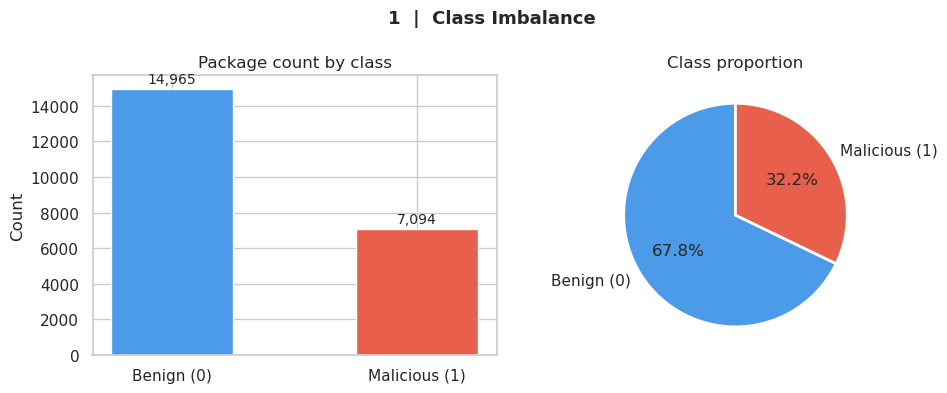

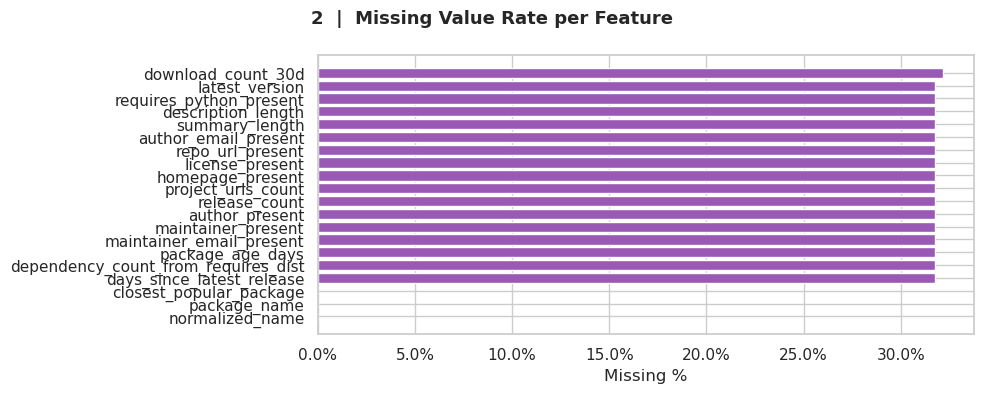

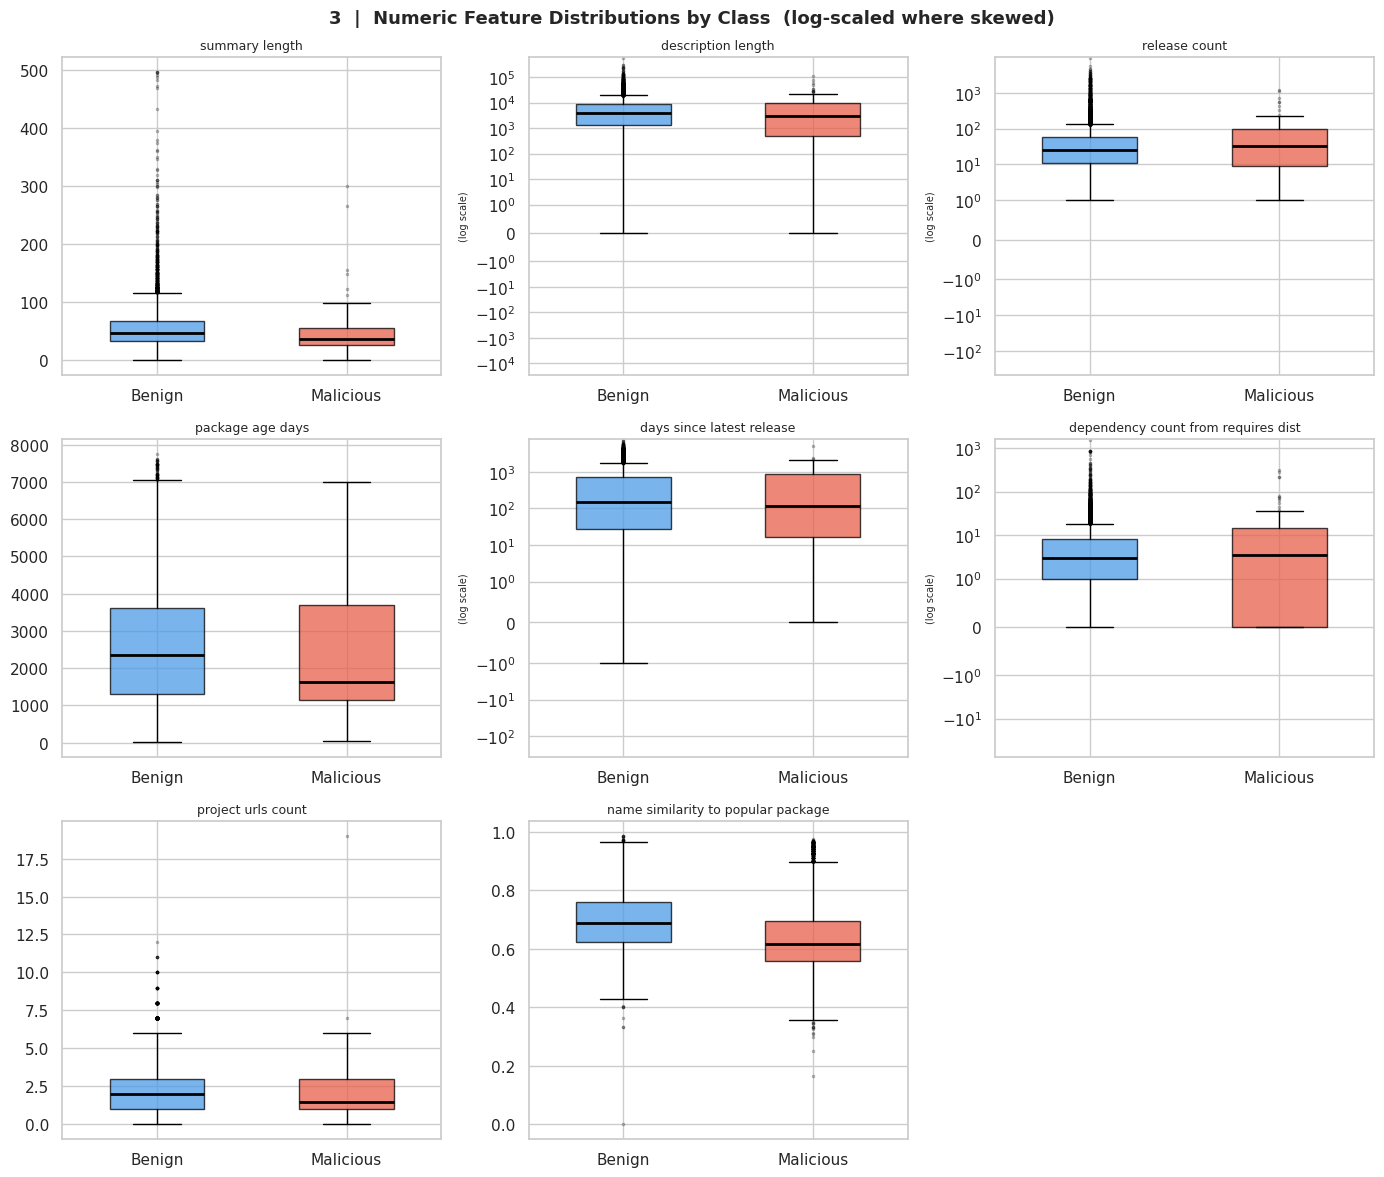

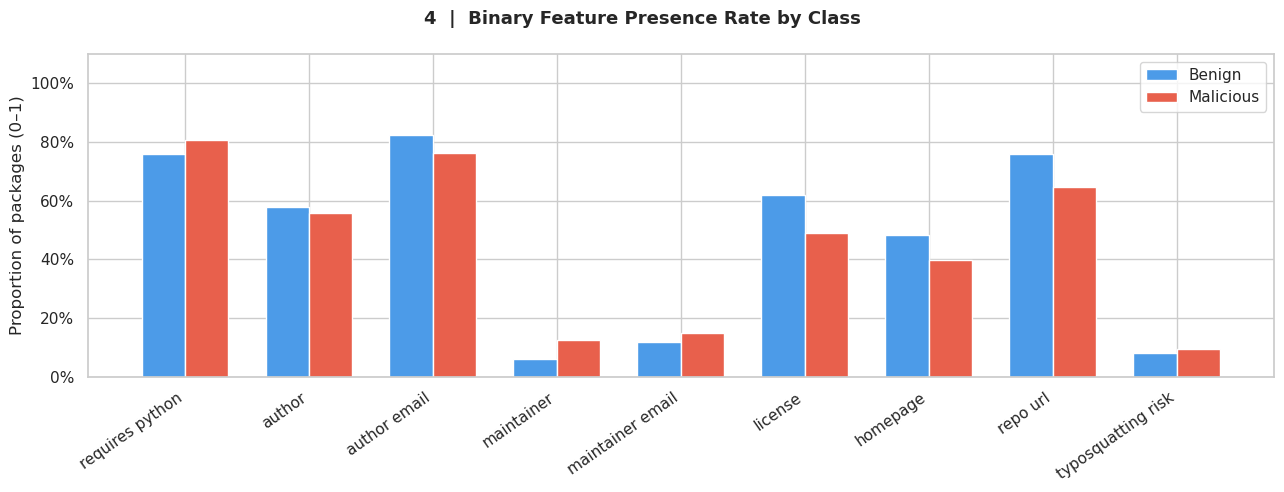

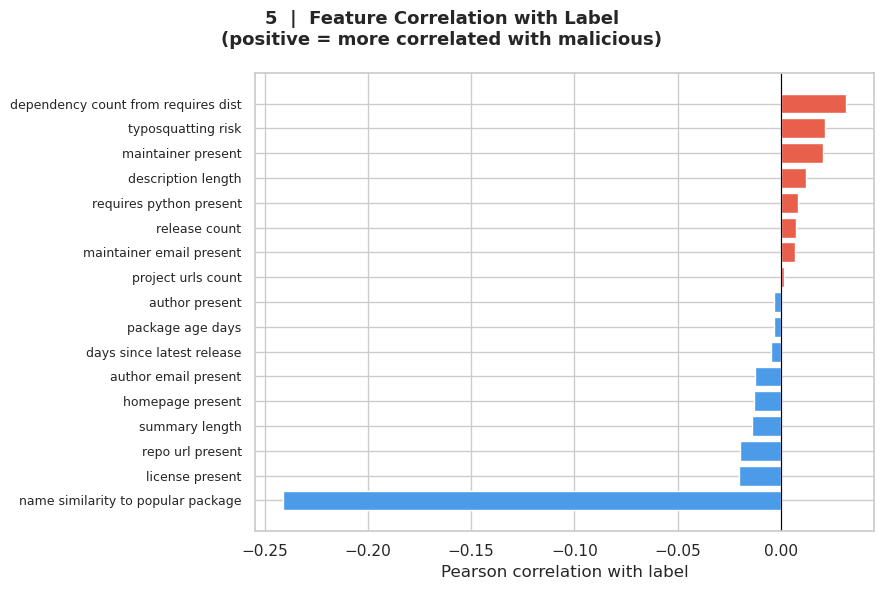

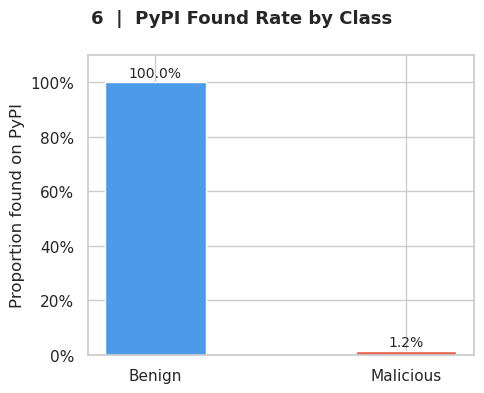

Charts saved to supply_chain_risk_dataset/processed


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="muted")
except ImportError:
    sns = None
    print("seaborn not installed — falling back to plain matplotlib.")

_df = ml_df.copy()
_df["label"] = _df["label"].astype(int)
_df["label_name"] = _df["label"].map({0: "Benign", 1: "Malicious"})

COLORS = {0: "#4C9BE8", 1: "#E8604C"}
LABEL_COLORS = ["#4C9BE8", "#E8604C"]

numeric_feature_cols = [c for c in [
    "summary_length", "description_length", "release_count",
    "package_age_days", "days_since_latest_release",
    "dependency_count_from_requires_dist", "project_urls_count",
    "name_similarity_to_popular_package",
] if c in _df.columns]

binary_cols = [c for c in [
    "requires_python_present", "author_present", "author_email_present",
    "maintainer_present", "maintainer_email_present",
    "license_present", "homepage_present", "repo_url_present", "typosquatting_risk",
] if c in _df.columns]

# ── 1. Class imbalance ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("1  |  Class Imbalance", fontsize=13, fontweight="bold")

counts = _df["label"].value_counts().sort_index()
_label_name_map = {0: "Benign (0)", 1: "Malicious (1)"}
_color_map = {0: "#4C9BE8", 1: "#E8604C"}
labels_txt = [_label_name_map[k] for k in counts.index]
pie_colors = [_color_map[k] for k in counts.index]

axes[0].bar(labels_txt, counts.values, color=pie_colors, edgecolor="white", width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts.values) * 0.01, f"{v:,}", ha="center", va="bottom", fontsize=10)
axes[0].set_ylabel("Count")
axes[0].set_title("Package count by class")

axes[1].pie(
    counts.values,
    labels=labels_txt,
    colors=pie_colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Class proportion")

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "eda_class_imbalance.png"), dpi=120, bbox_inches="tight")
plt.show()

# ── 2. Missing values bar chart ───────────────────────────────
missing_pct = (_df.isnull().sum() / len(_df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if missing_pct.empty:
    print("No missing values — skipping missing-value chart.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.suptitle("2  |  Missing Value Rate per Feature", fontsize=13, fontweight="bold")
    ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color="#9B59B6", edgecolor="white")
    ax.set_xlabel("Missing %")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "eda_missing_values.png"), dpi=120, bbox_inches="tight")
    plt.show()

# ── 3. Numeric feature distributions by class (box plots) ─────
n_cols = 3
n_rows = int(np.ceil(len(numeric_feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
fig.suptitle("3  |  Numeric Feature Distributions by Class  (log-scaled where skewed)", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(numeric_feature_cols):
    ax = axes[i]
    groups = [
        _df.loc[_df["label"] == lbl, col].dropna().values
        for lbl in [0, 1]
    ]
    bp = ax.boxplot(
        groups,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 2},
        flierprops={"marker": ".", "markersize": 3, "alpha": 0.3},
        widths=0.5,
    )
    for patch, color in zip(bp["boxes"], LABEL_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Benign", "Malicious"])
    ax.set_title(col.replace("_", " "), fontsize=9)
    # Apply log scale if range is large
    vals = _df[col].dropna()
    if vals.max() > 0 and vals.max() / max(vals.median(), 1) > 50:
        ax.set_yscale("symlog", linthresh=1)
        ax.set_ylabel("(log scale)", fontsize=7)

for j in range(len(numeric_feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "eda_numeric_distributions.png"), dpi=120, bbox_inches="tight")
plt.show()

# ── 4. Binary feature presence rates ─────────────────────────
flag_rates = _df.groupby("label")[binary_cols].mean().T.rename(
    columns={k: v for k, v in {0: "Benign", 1: "Malicious"}.items() if k in _df["label"].unique()}
)

x = np.arange(len(binary_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle("4  |  Binary Feature Presence Rate by Class", fontsize=13, fontweight="bold")

if "Benign" in flag_rates.columns:
    ax.bar(x - width / 2, flag_rates["Benign"].values, width, label="Benign", color=COLORS[0], edgecolor="white")
if "Malicious" in flag_rates.columns:
    ax.bar(x + width / 2, flag_rates["Malicious"].values, width, label="Malicious", color=COLORS[1], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([c.replace("_present", "").replace("_", " ") for c in binary_cols], rotation=35, ha="right")
ax.set_ylabel("Proportion of packages (0–1)")
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "eda_binary_feature_rates.png"), dpi=120, bbox_inches="tight")
plt.show()

# ── 5. Feature correlation with label ─────────────────────────
all_feat_cols = numeric_feature_cols + binary_cols
corr = (
    _df[all_feat_cols + ["label"]]
    .apply(lambda c: c.corr(_df["label"]) if c.name != "label" else None)
    .dropna()
    .sort_values()
)

colors_corr = [COLORS[1] if v > 0 else COLORS[0] for v in corr.values]
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle("5  |  Feature Correlation with Label\n(positive = more correlated with malicious)", fontsize=13, fontweight="bold")
ax.barh(corr.index, corr.values, color=colors_corr, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with label")
ax.set_yticklabels([c.replace("_", " ") for c in corr.index], fontsize=9)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "eda_feature_correlation.png"), dpi=120, bbox_inches="tight")
plt.show()

# ── 6. PyPI found rate by class ───────────────────────────────
if "pypi_found" in _df.columns:
    found_rate = _df.groupby("label_name")["pypi_found"].mean()
    fig, ax = plt.subplots(figsize=(5, 4))
    fig.suptitle("6  |  PyPI Found Rate by Class", fontsize=13, fontweight="bold")
    ax.bar(found_rate.index, found_rate.values,
           color=[COLORS[0] if x == "Benign" else COLORS[1] for x in found_rate.index],
           edgecolor="white", width=0.4)
    ax.set_ylabel("Proportion found on PyPI")
    ax.set_ylim(0, 1.1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for i, (name, val) in enumerate(found_rate.items()):
        ax.text(i, val + 0.02, f"{val:.1%}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "eda_pypi_found_rate.png"), dpi=120, bbox_inches="tight")
    plt.show()

print("Charts saved to", PROCESSED_DIR)


# Part G — Model Training & Comparison

Trains three models on the **leakage-free** feature set (no `pypi_found`, no `download_count_30d`):

1. **Logistic Regression** — linear baseline, interpretable coefficients
2. **Random Forest** — non-linear ensemble, robust to outliers
3. **XGBoost** — gradient-boosted trees, best performance expected

### Feature strategy
- **Name-derived features** (always present): no imputation needed
- **PyPI metadata features** (NaN for removed packages): median imputation via `SimpleImputer` for LR/RF; XGBoost handles NaN natively

### Split: 70 / 15 / 15 (train / val / test)
Val set used for model selection; test set is held out and used **once** for final reporting.


Model features (28):
  summary_length
  description_length
  requires_python_present
  author_present
  author_email_present
  maintainer_present
  maintainer_email_present
  license_present
  homepage_present
  project_urls_count
  repo_url_present
  dependency_count_from_requires_dist
  release_count
  package_age_days
  days_since_latest_release
  name_similarity_to_popular_package
  typosquatting_risk
  name_length
  name_entropy
  digit_count
  has_digits
  hyphen_count
  underscore_count
  dot_count
  starts_with_py
  ends_with_py
  all_lowercase
  has_special_chars
All feature columns are numeric.
float64    28
Name: count, dtype: int64

Dataset: 22,059 rows × 28 features
Label counts:
label
benign       14965
malicious     7094

Split → train: 15,440  val: 3,310  test: 3,309
Class imbalance weight (benign:malicious) = 2:1

Training Logistic Regression... 

ROC-AUC=0.9961  F1=0.9948

Training Random Forest... 

ROC-AUC=0.9968  F1=0.9948

Training XGBoost... 

ROC-AUC=0.9972  F1=0.9929

MODEL COMPARISON — Validation Set
                     ROC-AUC  PR-AUC      F1  Precision  Recall
XGBoost               0.9972  0.9969  0.9929     0.9962  0.9897
Random Forest         0.9968  0.9964  0.9948     1.0000  0.9897
Logistic Regression   0.9961  0.9964  0.9948     1.0000  0.9897

BEST MODEL: XGBoost  (final held-out test-set evaluation)
              precision    recall  f1-score   support

      benign     0.9947    0.9973    0.9960      2245
   malicious     0.9943    0.9887    0.9915      1064

    accuracy                         0.9946      3309
   macro avg     0.9945    0.9930    0.9938      3309
weighted avg     0.9946    0.9946    0.9946      3309

ROC-AUC : 0.9967
PR-AUC  : 0.9954


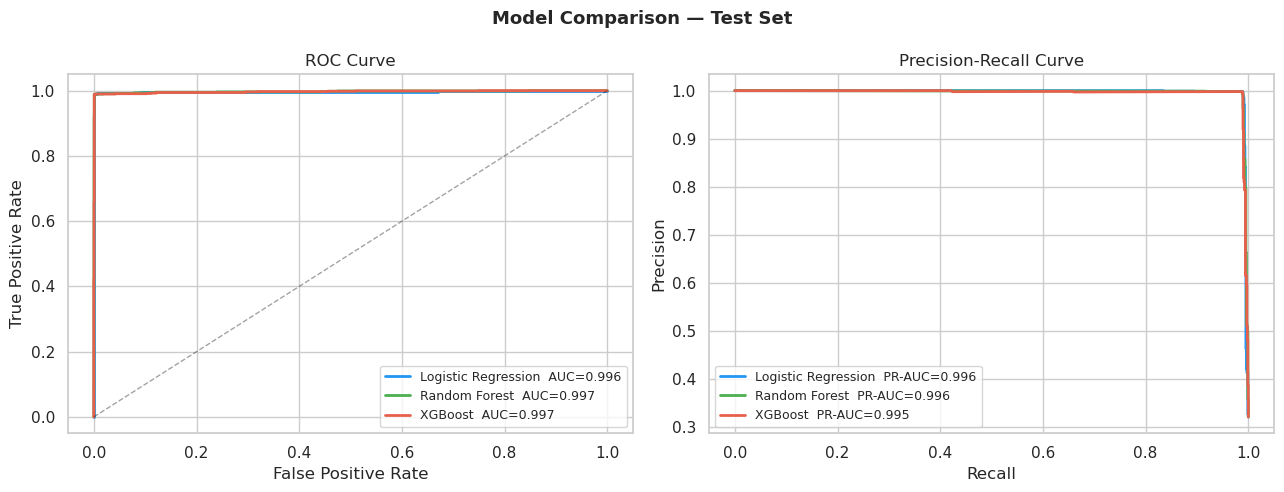

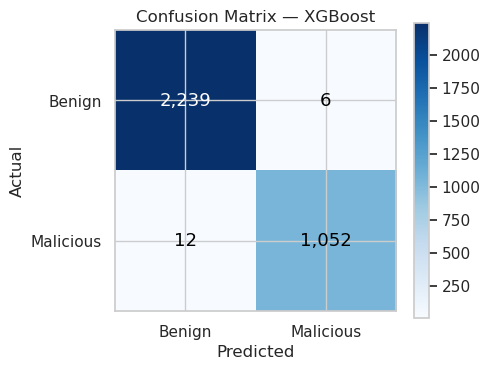

Saved 3 rows -> supply_chain_risk_dataset/processed/model_comparison_results.csv

Saved: best_model_pipeline.pkl  (model=XGBoost)
Saved: feature_cols.pkl  (28 features)


In [16]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)

# ── 1. Define leaky and non-feature columns ───────────────────
# pypi_found:        direct leakage (0 = removed = malicious)
# download_count_30d: only populated for benign class (from top-pypi CSV)
LEAKY_FEATURES = {"pypi_found", "download_count_30d"}
NON_FEATURES = {
    "package_name", "normalized_name", "ecosystem",
    "label", "label_source", "latest_version", "closest_popular_package",
}

feature_cols = [
    c for c in ml_df.columns
    if c not in NON_FEATURES
    and c not in LEAKY_FEATURES
    and ml_df[c].dtype in ["int64", "float64", "int32", "float32"]
]
print(f"Model features ({len(feature_cols)}):\n  " + "\n  ".join(feature_cols))

# Ensure all model features are numeric before training
# XGBoost requires int, float, bool, or category columns.

for col in feature_cols:
    ml_df[col] = pd.to_numeric(ml_df[col], errors="coerce")

ml_df[feature_cols] = ml_df[feature_cols].fillna(-1.0).astype("float64")

# Sanity check
_bad_dtypes = ml_df[feature_cols].select_dtypes(include=["object"]).columns.tolist()

if _bad_dtypes:
    raise ValueError(f"Non-numeric feature columns still present: {_bad_dtypes}")

print("All feature columns are numeric.")
print(ml_df[feature_cols].dtypes.value_counts())

# ── 2. Prepare X / y ──────────────────────────────────────────
ml_df = ml_df.dropna(subset=["label"]).copy()
X = ml_df[feature_cols]           # NaN kept — each pipeline handles it
y = ml_df["label"].astype(int)

print(f"\nDataset: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Label counts:\n{y.value_counts().rename({0: 'benign', 1: 'malicious'}).to_string()}")

if y.nunique() < 2:
    print("\nNeed both classes. Re-run earlier cells with a larger MAX_PACKAGES_TO_ENRICH.")
else:
    # ── 3. Stratified 70 / 15 / 15 split ─────────────────────
    X_tmp, X_test, y_tmp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_tmp, y_tmp, test_size=round(0.15 / 0.85, 4), random_state=42, stratify=y_tmp
    )
    print(f"\nSplit → train: {len(y_train):,}  val: {len(y_val):,}  test: {len(y_test):,}")

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    spw = max(1, round(neg / max(pos, 1)))   # floor to 1 so XGBoost never ignores positive class
    print(f"Class imbalance weight (benign:malicious) = {spw}:1")

    # ── 4. Define three pipelines ─────────────────────────────
    pipelines = {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
            ("model",   LogisticRegression(
                max_iter=1000, class_weight="balanced",
                C=0.1, random_state=42,
            )),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model",   RandomForestClassifier(
                n_estimators=300, max_depth=10,
                class_weight="balanced", random_state=42, n_jobs=-1,
            )),
        ]),
        "XGBoost": Pipeline([
            # No imputer — XGBoost learns the best split direction for NaN values
            ("model", XGBClassifier(
                n_estimators=300, max_depth=4, learning_rate=0.05,
                subsample=0.9, colsample_bytree=0.9,
                eval_metric="logloss", random_state=42,
                scale_pos_weight=spw,
            )),
        ]),
    }

    # ── 5. Train all models, evaluate on val set ──────────────
    val_results = {}
    trained_pipelines = {}

    for name, pipe in pipelines.items():
        print(f"\nTraining {name}...", end=" ")
        pipe.fit(X_train, y_train)
        trained_pipelines[name] = pipe

        pred_v = pipe.predict(X_val)
        prob_v = pipe.predict_proba(X_val)[:, 1]
        cr = classification_report(y_val, pred_v, output_dict=True, zero_division=0)

        val_results[name] = {
            "ROC-AUC":   round(roc_auc_score(y_val, prob_v), 4),
            "PR-AUC":    round(average_precision_score(y_val, prob_v), 4),
            "F1":        round(cr["1"]["f1-score"], 4),
            "Precision": round(cr["1"]["precision"], 4),
            "Recall":    round(cr["1"]["recall"], 4),
        }
        print(f"ROC-AUC={val_results[name]['ROC-AUC']:.4f}  F1={val_results[name]['F1']:.4f}")

    # ── 6. Comparison table ───────────────────────────────────
    val_df = pd.DataFrame(val_results).T.sort_values("ROC-AUC", ascending=False)
    print("\n" + "=" * 60)
    print("MODEL COMPARISON — Validation Set")
    print("=" * 60)
    print(val_df.to_string())

    # ── 7. Best model → held-out test set ────────────────────
    best_name = val_df["ROC-AUC"].idxmax()
    best_pipe = trained_pipelines[best_name]
    pred_t  = best_pipe.predict(X_test)
    prob_t  = best_pipe.predict_proba(X_test)[:, 1]

    print(f"\n{'='*60}")
    print(f"BEST MODEL: {best_name}  (final held-out test-set evaluation)")
    print("=" * 60)
    print(classification_report(y_test, pred_t,
          target_names=["benign", "malicious"], digits=4, zero_division=0))
    print(f"ROC-AUC : {roc_auc_score(y_test, prob_t):.4f}")
    print(f"PR-AUC  : {average_precision_score(y_test, prob_t):.4f}")

    # ── 8. ROC + PR curves — all models on test set ───────────
    CURVE_COLORS = {
        "Logistic Regression": "#2196F3",
        "Random Forest":       "#4CAF50",
        "XGBoost":             "#E8604C",
    }
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model Comparison — Test Set", fontsize=13, fontweight="bold")

    for name, pipe in trained_pipelines.items():
        p = pipe.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, p)
        axes[0].plot(fpr, tpr, lw=2, color=CURVE_COLORS[name],
                     label=f"{name}  AUC={roc_auc_score(y_test, p):.3f}")
        prec, rec, _ = precision_recall_curve(y_test, p)
        axes[1].plot(rec, prec, lw=2, color=CURVE_COLORS[name],
                     label=f"{name}  PR-AUC={average_precision_score(y_test, p):.3f}")

    axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
    axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
    axes[0].legend(fontsize=9)
    axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "model_comparison_curves.png"), dpi=120, bbox_inches="tight")
    plt.show()

    # ── 9. Confusion matrix for best model ────────────────────
    cm = confusion_matrix(y_test, pred_t)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Benign", "Malicious"])
    ax.set_yticklabels(["Benign", "Malicious"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {best_name}")
    plt.colorbar(im, ax=ax)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center", fontsize=13,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "confusion_matrix.png"), dpi=120, bbox_inches="tight")
    plt.show()

    # ── 10. Save artifacts ────────────────────────────────────
    joblib.dump(best_pipe,    str(PROCESSED_DIR / "best_model_pipeline.pkl"))
    joblib.dump(feature_cols, str(PROCESSED_DIR / "feature_cols.pkl"))
    save_csv(val_df.reset_index().rename(columns={"index": "model"}),
             "model_comparison_results.csv")
    print(f"\nSaved: best_model_pipeline.pkl  (model={best_name})")
    print(f"Saved: feature_cols.pkl  ({len(feature_cols)} features)")


# Part H — Explainability with SHAP

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions, satisfying the project requirement for **explainable AI**.

Three plots:
1. **Beeswarm summary** — shows the distribution of SHAP values per feature across all test samples
2. **Bar importance** — mean |SHAP| ranked importance
3. **Waterfall** — single highest-risk malicious package, showing exactly which features drove the prediction


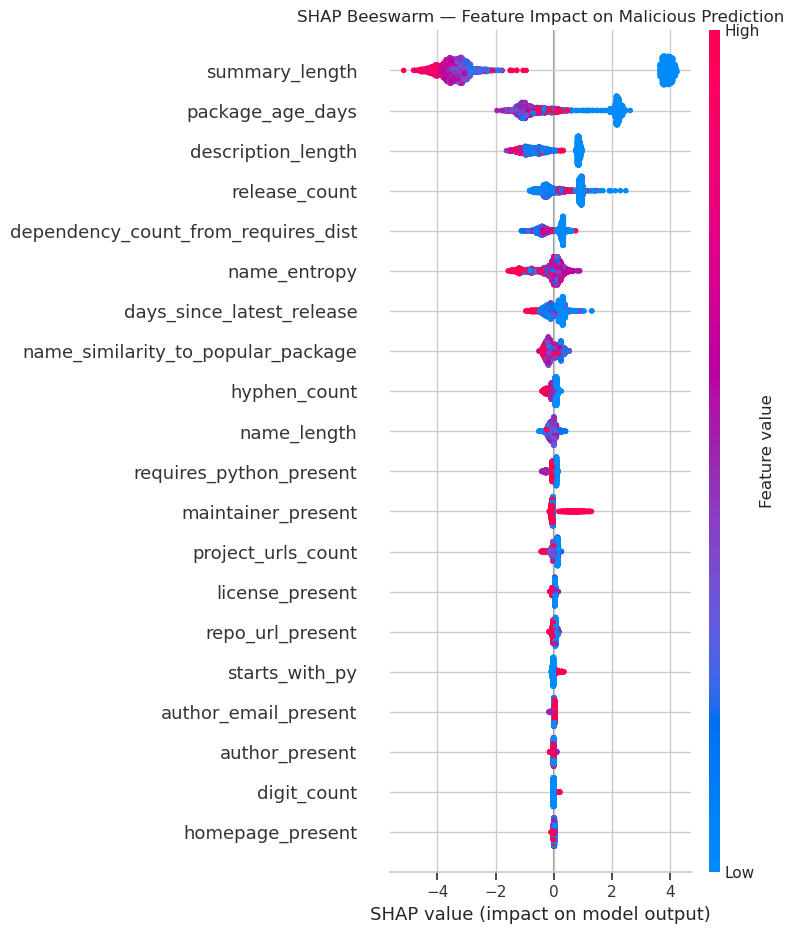

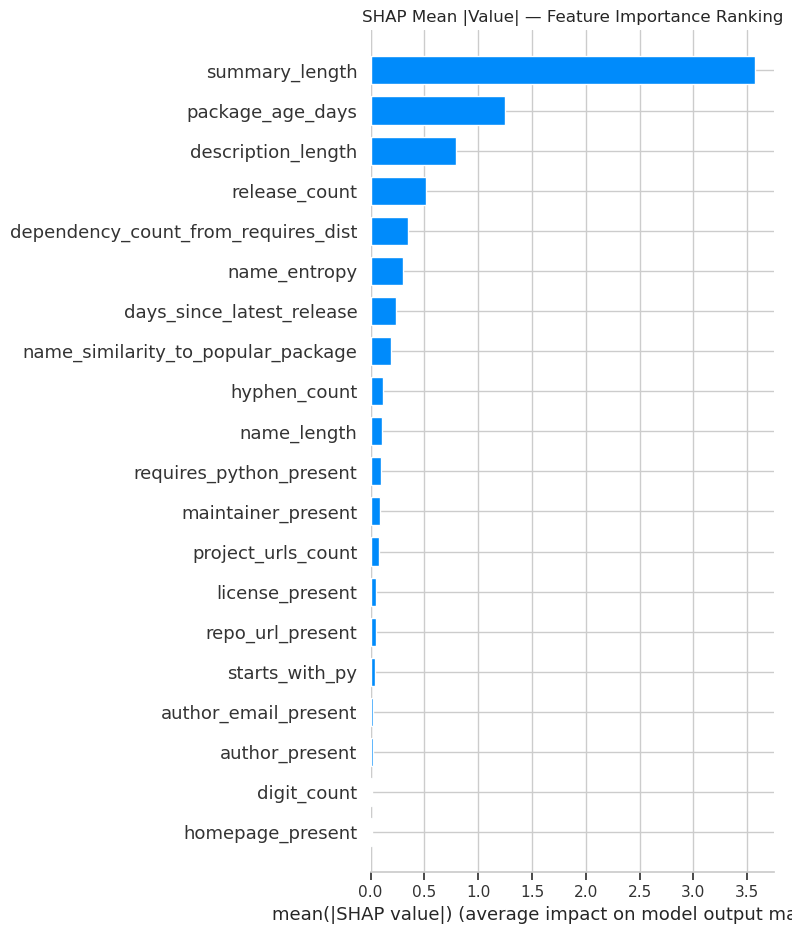

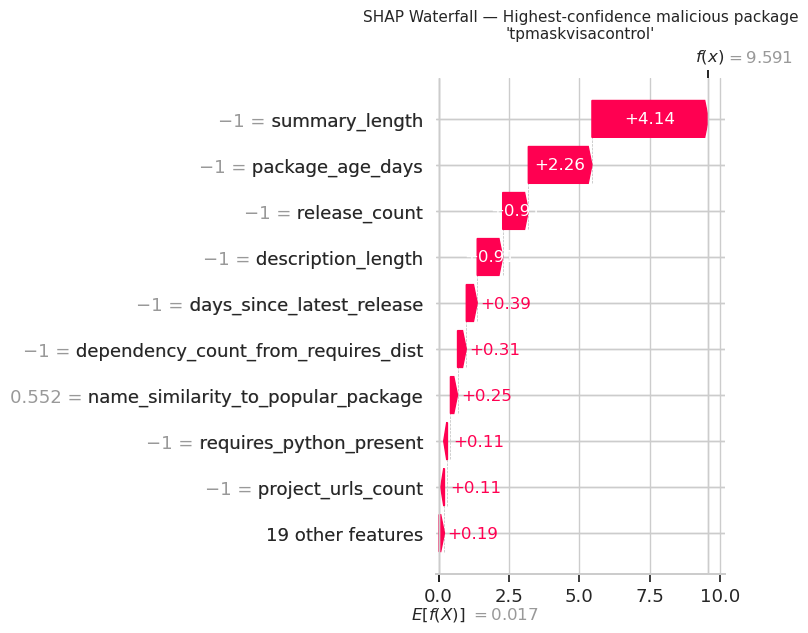

Waterfall shown for package: 'tpmaskvisacontrol'

SHAP plots saved to supply_chain_risk_dataset/processed


In [17]:
try:
    import shap
    shap.initjs()

    # Use the XGBoost model for SHAP (tree explainer is exact, not approximate)
    xgb_pipe  = trained_pipelines["XGBoost"]
    xgb_model = xgb_pipe.named_steps["model"]

    # XGBoost was trained on raw X with NaN — pass the same to the explainer
    X_shap = X_test.copy()

    explainer   = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)

    # ── Plot 1: Beeswarm summary ──────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values, X_shap,
        feature_names=feature_cols,
        show=False,
    )
    plt.title("SHAP Beeswarm — Feature Impact on Malicious Prediction", fontsize=12)
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "shap_beeswarm.png"), dpi=120, bbox_inches="tight")
    plt.show()

    # ── Plot 2: Bar importance (mean |SHAP|) ──────────────────
    plt.figure(figsize=(9, 6))
    shap.summary_plot(
        shap_values, X_shap,
        feature_names=feature_cols,
        plot_type="bar",
        show=False,
    )
    plt.title("SHAP Mean |Value| — Feature Importance Ranking", fontsize=12)
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "shap_bar_importance.png"), dpi=120, bbox_inches="tight")
    plt.show()

    # ── Plot 3: Waterfall for highest-risk malicious sample ───
    mal_idx_arr = np.where(y_test.values == 1)[0]
    if len(mal_idx_arr) > 0:
        # Pick the test sample the model is most confident is malicious
        highest_risk_pos = mal_idx_arr[prob_t[mal_idx_arr].argmax()]
        pkg_name = ml_df.iloc[X_test.index[highest_risk_pos]]["package_name"]

        shap.waterfall_plot(
            shap.Explanation(
                values       = shap_values[highest_risk_pos],
                base_values  = explainer.expected_value,
                data         = X_shap.iloc[highest_risk_pos].values,
                feature_names= feature_cols,
            ),
            show=False,
        )
        plt.title(
            f"SHAP Waterfall — Highest-confidence malicious package\n'{pkg_name}'",
            fontsize=11,
        )
        plt.tight_layout()
        plt.savefig(str(PROCESSED_DIR / "shap_waterfall_example.png"), dpi=120, bbox_inches="tight")
        plt.show()
        print(f"Waterfall shown for package: '{pkg_name}'")

    print("\nSHAP plots saved to", PROCESSED_DIR)

except ImportError:
    print("shap not installed. Run:  pip install shap  then re-run this cell.")
except Exception as e:
    print(f"SHAP error: {e}")
    raise


# Part I — SageMaker Deployment

## Architecture

```
Local notebook
  └── best_model_pipeline.pkl  (sklearn Pipeline: imputer → scaler → model)
        │
        ▼  packaged as model.tar.gz
  S3 bucket  (supply-chain-risk/models/)
        │
        ▼  SageMaker Model object (SKLearn framework container)
  SageMaker Endpoint  (ml.t2.medium or ml.m5.large)
        │
        ▼  REST API  (InvokeEndpoint)
  Client / batch job
```

## Prerequisites
1. Run this notebook inside **SageMaker Studio** or an EC2 instance with a SageMaker execution role, **or** configure `boto3` locally with an IAM user that has `sagemaker:*` and `s3:*` permissions.
2. Set `S3_BUCKET` below to your bucket name (or leave blank to use the SageMaker default bucket).

## Steps covered here
- Package the trained pipeline as `model.tar.gz`
- Upload to S3
- Create a SageMaker Model with the SKLearn framework container
- Deploy a real-time endpoint
- Run a sample prediction
- (Optional) Delete the endpoint to avoid charges


In [18]:
# import boto3
# import json

# sm = boto3.client("sagemaker")

# desc = sm.describe_endpoint(EndpointName=ENDPOINT_NAME)

# print("EndpointName:", desc["EndpointName"])
# print("EndpointStatus:", desc["EndpointStatus"])
# print("EndpointConfigName:", desc.get("EndpointConfigName"))

# if "FailureReason" in desc:
#     print("\nFailureReason:")
#     print(desc["FailureReason"])

# print("\nFull useful details:")
# print(json.dumps(
#     {
#         "EndpointStatus": desc.get("EndpointStatus"),
#         "FailureReason": desc.get("FailureReason"),
#         "CreationTime": str(desc.get("CreationTime")),
#         "LastModifiedTime": str(desc.get("LastModifiedTime")),
#         "ProductionVariants": desc.get("ProductionVariants"),
#     },
#     indent=2,
#     default=str,
# ))

# import boto3
# from botocore.exceptions import ClientError

# logs = boto3.client("logs")

# log_group = f"/aws/sagemaker/Endpoints/{ENDPOINT_NAME}"

# print("Log group:", log_group)

# try:
#     streams = logs.describe_log_streams(
#         logGroupName=log_group,
#         orderBy="LastEventTime",
#         descending=True,
#         limit=5,
#     )

#     for stream in streams.get("logStreams", []):
#         stream_name = stream["logStreamName"]
#         print("\n" + "=" * 90)
#         print("Log stream:", stream_name)
#         print("=" * 90)

#         events = logs.get_log_events(
#             logGroupName=log_group,
#             logStreamName=stream_name,
#             startFromHead=False,
#             limit=100,
#         )

#         for event in events.get("events", []):
#             print(event["message"].rstrip())

# except ClientError as e:
#     print("Could not read CloudWatch logs.")
#     print(e)

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# Part J / Cell 18 — Package model.tar.gz and deploy SageMaker endpoint
# SageMaker SDK V3-compatible version
# ─────────────────────────────────────────────────────────────────────────────
# This version avoids old V2 imports:
#   - no sagemaker.sklearn.model.SKLearnModel
#   - no sagemaker.get_execution_role()
#   - no sagemaker.serializers / deserializers
#
# It uses:
#   - boto3 create_model / create_endpoint_config / create_endpoint
#   - SageMaker V3 image_uris.retrieve(...)
#   - SageMaker Runtime invoke_endpoint(...)
# ═══════════════════════════════════════════════════════════════════════════════

import os
import tarfile
import json
import shutil
import time
from pathlib import Path

# ── Validate required training artifacts ─────────────────────────────────────
required_artifacts = [
    PROCESSED_DIR / "best_model_pipeline.pkl",
    PROCESSED_DIR / "feature_cols.pkl",
]

missing = [str(p) for p in required_artifacts if not p.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing model artifacts from Part G: {missing}. Run model training first."
    )

# ── Step 1: Create SageMaker inference code ─────────────────────────────────
# SageMaker sklearn container calls model_fn / input_fn / predict_fn / output_fn.
INFERENCE_SCRIPT = """\
import json
import joblib
import os
import numpy as np
import pandas as pd


def model_fn(model_dir):
    pipeline  = joblib.load(os.path.join(model_dir, "best_model_pipeline.pkl"))
    feat_cols = joblib.load(os.path.join(model_dir, "feature_cols.pkl"))
    return {"pipeline": pipeline, "feature_cols": feat_cols}


def input_fn(request_body, content_type="application/json"):
    if content_type == "application/json":
        data = json.loads(request_body)
        return pd.DataFrame(data if isinstance(data, list) else [data])
    raise ValueError(f"Unsupported content type: {content_type}")


def predict_fn(input_data, model):
    pipeline  = model["pipeline"]
    feat_cols = model["feature_cols"]

    X = input_data.reindex(columns=feat_cols)

    proba  = pipeline.predict_proba(X)[:, 1]
    labels = pipeline.predict(X)

    return pd.DataFrame({
        "malicious_probability": proba.astype(float),
        "predicted_label": labels.astype(int),
    })


def output_fn(prediction, accept="application/json"):
    return prediction.to_json(orient="records"), "application/json"
"""

DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

(DEPLOY_DIR / "inference.py").write_text(INFERENCE_SCRIPT)

# Critical fix:
# If the selected model is XGBoost, the sklearn serving container needs xgboost
# available at inference time.
try:
    import xgboost
    xgb_req = f"xgboost=={xgboost.__version__}"
except Exception:
    xgb_req = "xgboost"

(DEPLOY_DIR / "requirements.txt").write_text(
    "\n".join([
        xgb_req,
        "pandas",
        "numpy",
        "joblib",
    ]) + "\n"
)

shutil.copy(
    str(PROCESSED_DIR / "best_model_pipeline.pkl"),
    str(DEPLOY_DIR / "best_model_pipeline.pkl"),
)

shutil.copy(
    str(PROCESSED_DIR / "feature_cols.pkl"),
    str(DEPLOY_DIR / "feature_cols.pkl"),
)

# ── Step 2: Package as model.tar.gz ─────────────────────────────────────────
model_tar_path = DEPLOY_DIR / "model.tar.gz"

with tarfile.open(model_tar_path, "w:gz") as tar:
    tar.add(str(DEPLOY_DIR / "inference.py"),            arcname="code/inference.py")
    tar.add(str(DEPLOY_DIR / "requirements.txt"),        arcname="code/requirements.txt")
    tar.add(str(DEPLOY_DIR / "best_model_pipeline.pkl"), arcname="best_model_pipeline.pkl")
    tar.add(str(DEPLOY_DIR / "feature_cols.pkl"),        arcname="feature_cols.pkl")

print("model.tar.gz created — contents:")

with tarfile.open(model_tar_path, "r:gz") as tar:
    for m in tar.getmembers():
        print(f"  {m.name}  ({m.size:,} bytes)")

# ── Step 3: Upload to S3 and deploy endpoint using Boto3 ────────────────────
try:
    import boto3
    from botocore.exceptions import ClientError
    from sagemaker.core.helper.session_helper import get_execution_role
    from sagemaker.core import image_uris

    boto_session = boto3.Session()
    region = (
        boto_session.region_name
        or os.environ.get("AWS_REGION")
        or os.environ.get("AWS_DEFAULT_REGION")
    )

    if not region:
        raise RuntimeError(
            "Could not determine AWS region. Run inside SageMaker Studio or configure AWS_DEFAULT_REGION."
        )

    sm = boto_session.client("sagemaker", region_name=region)
    s3 = boto_session.client("s3", region_name=region)
    sts = boto_session.client("sts", region_name=region)
    runtime = boto_session.client("sagemaker-runtime", region_name=region)

    account_id = sts.get_caller_identity()["Account"]

    bucket = None

    if "S3_BUCKET" in globals() and S3_BUCKET:
        bucket = S3_BUCKET
    elif "_bucket" in globals() and _bucket:
        bucket = _bucket
    else:
        bucket = f"sagemaker-{region}-{account_id}"

    role = get_execution_role()

    # Make sure model prefix is safe
    _model_prefix = S3_MODEL_PREFIX.strip("/") if "S3_MODEL_PREFIX" in globals() else "supply-chain-risk/models"
    _model_key = f"{_model_prefix}/model.tar.gz"

    print(f"\nUploading model artifact to S3...")
    print(f"  Bucket : {bucket}")
    print(f"  Key    : {_model_key}")

    s3.upload_file(
        Filename=str(model_tar_path),
        Bucket=bucket,
        Key=_model_key,
    )

    s3_model_uri = f"s3://{bucket}/{_model_key}"
    print(f"Model uploaded to: {s3_model_uri}")

    sklearn_image = image_uris.retrieve(
        framework="sklearn",
        region=region,
        version=SKLEARN_VERSION,
        py_version="py3",
        instance_type=INSTANCE_TYPE,
    )

    print(f"\nUsing sklearn image:")
    print(f"  {sklearn_image}")

    # Use names based on the endpoint name so cleanup is easy later.
    MODEL_NAME = f"{ENDPOINT_NAME}-model"
    ENDPOINT_CONFIG_NAME = f"{ENDPOINT_NAME}-config"

    # ── Create SageMaker Model ──────────────────────────────────────────────
    print(f"\nCreating SageMaker model: {MODEL_NAME}")

    try:
        sm.create_model(
            ModelName=MODEL_NAME,
            ExecutionRoleArn=role,
            PrimaryContainer={
                "Image": sklearn_image,
                "ModelDataUrl": s3_model_uri,
                "Environment": {
                    # These tell the sklearn serving container to run code/inference.py
                    "SAGEMAKER_PROGRAM": "inference.py",
                    "SAGEMAKER_SUBMIT_DIRECTORY": "/opt/ml/model/code",
                    "SAGEMAKER_CONTAINER_LOG_LEVEL": "20",
                    "SAGEMAKER_REGION": region,
                },
            },
        )
        print(f"  ✓ Created model: {MODEL_NAME}")

    except ClientError as e:
        if "already exists" in str(e).lower():
            print(f"  • Model already exists: {MODEL_NAME}")
        else:
            raise

    # ── Create Endpoint Config ──────────────────────────────────────────────
    print(f"\nCreating endpoint config: {ENDPOINT_CONFIG_NAME}")

    try:
        sm.create_endpoint_config(
            EndpointConfigName=ENDPOINT_CONFIG_NAME,
            ProductionVariants=[
                {
                    "VariantName": "AllTraffic",
                    "ModelName": MODEL_NAME,
                    "InitialInstanceCount": 1,
                    "InstanceType": INSTANCE_TYPE,
                    "InitialVariantWeight": 1.0,
                }
            ],
        )
        print(f"  ✓ Created endpoint config: {ENDPOINT_CONFIG_NAME}")

    except ClientError as e:
        if "already exists" in str(e).lower():
            print(f"  • Endpoint config already exists: {ENDPOINT_CONFIG_NAME}")
        else:
            raise

    # ── Create or update Endpoint ───────────────────────────────────────────
    print(f"\nDeploying endpoint '{ENDPOINT_NAME}' on {INSTANCE_TYPE}...")

    endpoint_exists = False

    try:
        sm.describe_endpoint(EndpointName=ENDPOINT_NAME)
        endpoint_exists = True
    except ClientError as e:
        if "Could not find endpoint" in str(e) or "ValidationException" in str(e):
            endpoint_exists = False
        else:
            raise

    if endpoint_exists:
        print(f"  • Endpoint already exists. Updating endpoint: {ENDPOINT_NAME}")
        sm.update_endpoint(
            EndpointName=ENDPOINT_NAME,
            EndpointConfigName=ENDPOINT_CONFIG_NAME,
        )
    else:
        sm.create_endpoint(
            EndpointName=ENDPOINT_NAME,
            EndpointConfigName=ENDPOINT_CONFIG_NAME,
        )

    print("Waiting for endpoint to reach InService status...")

    waiter = sm.get_waiter("endpoint_in_service")
    waiter.wait(
        EndpointName=ENDPOINT_NAME,
        WaiterConfig={
            "Delay": 30,
            "MaxAttempts": 40,
        },
    )

    print(f"Endpoint '{ENDPOINT_NAME}' is live.")

    # ── Step 4: Sample prediction using SageMaker Runtime ───────────────────
    sample = {
        col: float(X_test.iloc[0][col]) if pd.notna(X_test.iloc[0][col]) else None
        for col in feature_cols
    }

    payload = json.dumps([sample])

    invoke_resp = runtime.invoke_endpoint(
        EndpointName=ENDPOINT_NAME,
        ContentType="application/json",
        Accept="application/json",
        Body=payload,
    )

    response_body = invoke_resp["Body"].read().decode("utf-8")

    try:
        response = json.loads(response_body)
    except Exception:
        response = response_body

    print("\nSample prediction response:")
    print(json.dumps(response, indent=2) if isinstance(response, (dict, list)) else response)

    # Save a copy of the sample response for the report/video evidence.
    sample_output_path = PROCESSED_DIR / "sample_endpoint_prediction.json"

    with open(sample_output_path, "w") as f:
        json.dump(
            {
                "endpoint_name": ENDPOINT_NAME,
                "model_name": MODEL_NAME,
                "endpoint_config_name": ENDPOINT_CONFIG_NAME,
                "model_s3_uri": s3_model_uri,
                "response": response,
            },
            f,
            indent=2,
        )

    print(f"Saved: {sample_output_path}")

    if AUTO_DELETE_ENDPOINT_AFTER_TEST:
        print("\nAUTO_DELETE_ENDPOINT_AFTER_TEST=True, deleting endpoint now...")

        sm.delete_endpoint(EndpointName=ENDPOINT_NAME)

        try:
            deleted_waiter = sm.get_waiter("endpoint_deleted")
            deleted_waiter.wait(
                EndpointName=ENDPOINT_NAME,
                WaiterConfig={
                    "Delay": 20,
                    "MaxAttempts": 30,
                },
            )
        except Exception:
            pass

        try:
            sm.delete_endpoint_config(EndpointConfigName=ENDPOINT_CONFIG_NAME)
            print(f"Deleted endpoint config: {ENDPOINT_CONFIG_NAME}")
        except Exception as cleanup_exc:
            print(f"Endpoint config cleanup note: {cleanup_exc}")

        try:
            sm.delete_model(ModelName=MODEL_NAME)
            print(f"Deleted model: {MODEL_NAME}")
        except Exception as cleanup_exc:
            print(f"Model cleanup note: {cleanup_exc}")

        print("Endpoint deleted.")

    else:
        print("\nEndpoint left live for video/demo evidence.")
        print("When done, run the cleanup cell at the end or delete it in SageMaker Console.")

except ImportError as e:
    print(f"AWS/SageMaker import failed: {e}")
    print("This usually means the notebook has SDK V2 imports but the environment has SDK V3.")
    print(f"The SageMaker model artifact is ready locally at: {model_tar_path}")

except Exception as e:
    error_text = str(e).lower()

    if "execution role" in error_text or "credentials" in error_text or "unable to locate credentials" in error_text:
        print("AWS credentials not configured in this environment.")
        print("Run this cell inside SageMaker Studio or configure AWS credentials.")
        print(f"The packaged model is at: {model_tar_path}")

    else:
        print("SageMaker deployment failed. The local model artifact was still created.")
        print(f"Error: {e}")
        raise

model.tar.gz created — contents:
  code/inference.py  (1,094 bytes)
  code/requirements.txt  (35 bytes)
  best_model_pipeline.pkl  (401,273 bytes)
  feature_cols.pkl  (574 bytes)


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml



Uploading model artifact to S3...
  Bucket : sagemaker-us-east-1-617143422219
  Key    : supply-chain-risk/models/model.tar.gz
Model uploaded to: s3://sagemaker-us-east-1-617143422219/supply-chain-risk/models/model.tar.gz

Using sklearn image:
  683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.4-2-cpu-py3

Creating SageMaker model: supply-chain-risk-endpoint-20260615-061841-model


  ✓ Created model: supply-chain-risk-endpoint-20260615-061841-model

Creating endpoint config: supply-chain-risk-endpoint-20260615-061841-config


  ✓ Created endpoint config: supply-chain-risk-endpoint-20260615-061841-config

Deploying endpoint 'supply-chain-risk-endpoint-20260615-061841' on ml.m5.large...


Waiting for endpoint to reach InService status...


Endpoint 'supply-chain-risk-endpoint-20260615-061841' is live.

Sample prediction response:
[
  {
    "malicious_probability": 0.9997894168,
    "predicted_label": 1
  }
]
Saved: supply_chain_risk_dataset/processed/sample_endpoint_prediction.json

Endpoint left live for video/demo evidence.
When done, run the cleanup cell at the end or delete it in SageMaker Console.


# Part J — Model Monitoring & Data Drift Detection

Two-level monitoring strategy:

1. **Offline drift check** (this cell) — runs locally using KS-test and population stability index (PSI) to compare training feature distributions against any new batch of packages. Run this periodically (e.g., weekly) on newly scraped packages.

2. **SageMaker Model Monitor** (code stub below) — attach to the deployed endpoint to automatically capture traffic, compare distributions against a baseline, and alert on drift. Zero custom code required.


DRIFT REPORT — Training vs. Test distributions
(In production, replace X_test with a new batch of packages)


                            feature  ks_statistic  ks_p_value    psi  drifted_ks  drifted_psi
                       name_entropy        0.0168    0.424335 0.0034       False        False
                 description_length        0.0165    0.439773 0.0022       False        False
          days_since_latest_release        0.0126    0.772357 0.0023       False        False
           maintainer_email_present        0.0125    0.785902 0.0000       False        False
                        name_length        0.0124    0.793512 0.0018       False        False
                   package_age_days        0.0109    0.899297 0.0013       False        False
dependency_count_from_requires_dist        0.0103    0.932696 0.0010       False        False
                 maintainer_present        0.0085    0.988373 0.0000       False        False
 name_similarity_to_popular_package        0.0083    0.991228 0.0018       False        False
                      release_count        0.0081    0.99304

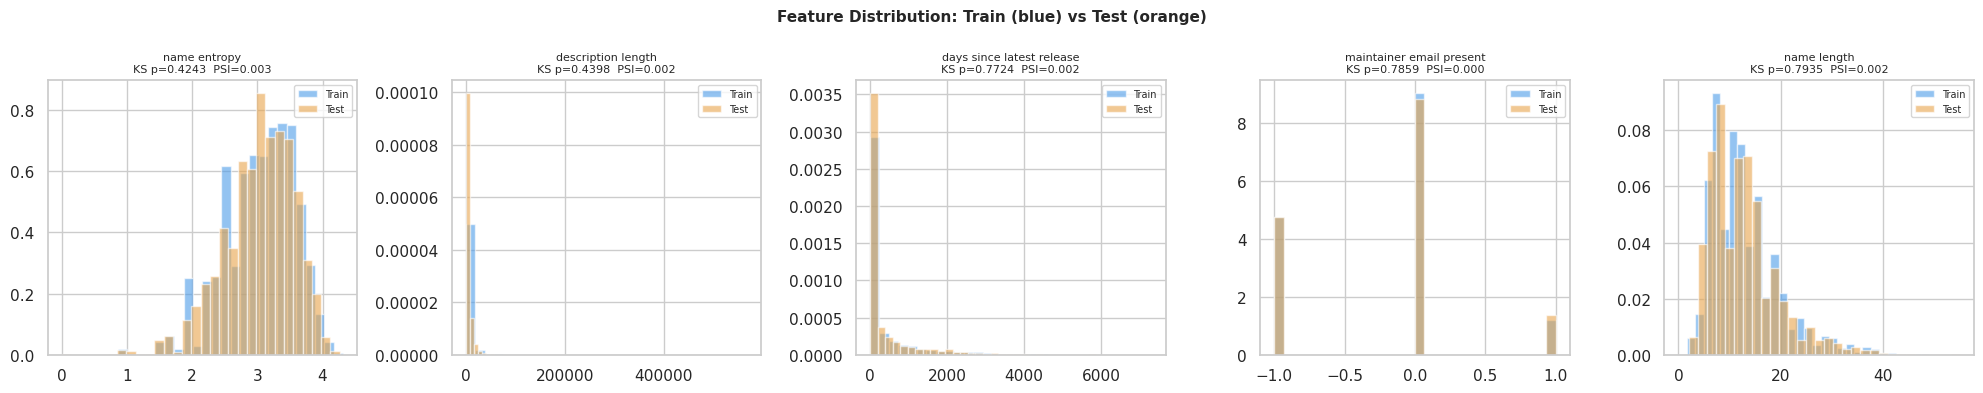

Saved 28 rows -> supply_chain_risk_dataset/processed/drift_report.csv

SageMaker Model Monitor — attach to live endpoint (run inside SageMaker Studio):

  from sagemaker.model_monitor import DefaultModelMonitor, CronExpressionGenerator

  monitor = DefaultModelMonitor(role=role, instance_count=1, instance_type="ml.m5.large")

  # Capture baseline statistics from training data
  monitor.suggest_baseline(
      baseline_dataset=f"s3://{bucket}/supply-chain-risk/baseline/train.csv",
      dataset_format=DatasetFormat.csv(header=True),
      output_s3_uri=f"s3://{bucket}/supply-chain-risk/baseline-results/",
  )

  # Schedule hourly drift checks
  monitor.create_monitoring_schedule(
      monitor_schedule_name="supply-chain-risk-monitor",
      endpoint_input=ENDPOINT_NAME,
      output_s3_uri=f"s3://{bucket}/supply-chain-risk/monitoring-reports/",
      statistics=monitor.baseline_statistics(),
      constraints=monitor.suggested_constraints(),
      schedule_cron_expression=CronExpressio

In [20]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Offline drift check ───────────────────────────────────────
# Simulates what you would do when a new batch of packages arrives.
# Replace X_new_batch with your actual new data DataFrame.

def compute_psi(expected: np.ndarray, actual: np.ndarray, buckets: int = 10) -> float:
    """Population Stability Index.  PSI < 0.1 = stable, 0.1-0.2 = monitor, >0.2 = retrain."""
    def _pct(arr, edges):
        counts, _ = np.histogram(arr, bins=edges)
        pct = counts / len(arr)
        return np.where(pct == 0, 1e-6, pct)

    edges = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    edges[0]  -= 1e-9
    edges[-1] += 1e-9
    e_pct = _pct(expected, edges)
    a_pct = _pct(actual,   edges)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))


def drift_report(X_train_ref: pd.DataFrame, X_new: pd.DataFrame,
                 feature_list: list, alpha: float = 0.05) -> pd.DataFrame:
    """
    KS-test + PSI for each feature.
    Returns a DataFrame sorted by KS p-value (smallest = most drifted).
    """
    rows = []
    for col in feature_list:
        ref = X_train_ref[col].dropna().values
        new = X_new[col].dropna().values
        if len(ref) < 5 or len(new) < 5:
            continue
        ks_stat, ks_p = stats.ks_2samp(ref, new)
        psi = compute_psi(ref, new)
        rows.append({
            "feature": col,
            "ks_statistic": round(ks_stat, 4),
            "ks_p_value":   round(ks_p,    6),
            "psi":          round(psi,      4),
            "drifted_ks":   ks_p < alpha,
            "drifted_psi":  psi > 0.2,
        })
    return pd.DataFrame(rows).sort_values("ks_p_value")


# Use test set as a proxy for "new production data"
print("=" * 60)
print("DRIFT REPORT — Training vs. Test distributions")
print("(In production, replace X_test with a new batch of packages)")
print("=" * 60)

drift_df = drift_report(X_train, X_test, feature_cols)
print(drift_df.to_string(index=False))

drifted = drift_df[drift_df["drifted_ks"] | drift_df["drifted_psi"]]
if drifted.empty:
    print("\nNo significant drift detected. Model is stable.")
else:
    print(f"\n⚠️  {len(drifted)} feature(s) show drift — consider retraining:")
    print(drifted[["feature", "ks_p_value", "psi"]].to_string(index=False))

# ── Visualise top-5 most drifted features ────────────────────
top5 = drift_df.head(5)["feature"].tolist()
if top5:
    fig, axes = plt.subplots(1, len(top5), figsize=(4 * len(top5), 4))
    if len(top5) == 1:
        axes = [axes]
    fig.suptitle("Feature Distribution: Train (blue) vs Test (orange)", fontsize=11, fontweight="bold")
    for ax, col in zip(axes, top5):
        ax.hist(X_train[col].dropna(), bins=30, alpha=0.6, density=True,
                color="#4C9BE8", label="Train")
        ax.hist(X_test[col].dropna(),  bins=30, alpha=0.6, density=True,
                color="#E8A44C", label="Test")
        row = drift_df[drift_df["feature"] == col].iloc[0]
        ax.set_title(f"{col.replace('_', ' ')}\nKS p={row['ks_p_value']:.4f}  PSI={row['psi']:.3f}",
                     fontsize=8)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "drift_top5_features.png"), dpi=120, bbox_inches="tight")
    plt.show()

save_csv(drift_df, "drift_report.csv")

# ── SageMaker Model Monitor (production use) ─────────────────
print("""
SageMaker Model Monitor — attach to live endpoint (run inside SageMaker Studio):

  from sagemaker.model_monitor import DefaultModelMonitor, CronExpressionGenerator

  monitor = DefaultModelMonitor(role=role, instance_count=1, instance_type="ml.m5.large")

  # Capture baseline statistics from training data
  monitor.suggest_baseline(
      baseline_dataset=f"s3://{bucket}/supply-chain-risk/baseline/train.csv",
      dataset_format=DatasetFormat.csv(header=True),
      output_s3_uri=f"s3://{bucket}/supply-chain-risk/baseline-results/",
  )

  # Schedule hourly drift checks
  monitor.create_monitoring_schedule(
      monitor_schedule_name="supply-chain-risk-monitor",
      endpoint_input=ENDPOINT_NAME,
      output_s3_uri=f"s3://{bucket}/supply-chain-risk/monitoring-reports/",
      statistics=monitor.baseline_statistics(),
      constraints=monitor.suggested_constraints(),
      schedule_cron_expression=CronExpressionGenerator.hourly(),
  )
""")


# Part K — S3 Data Storage

All project data is stored in S3 to satisfy the rubric requirement *"Your data should be stored in S3 and documented in your GitHub repository"*.

**Upload layout:**
```
s3://<bucket>/supply-chain-risk/
  raw/                          ← DataDog + OpenSSF manifests
  processed/                    ← CSVs, PNGs, model artifacts
```

Set `S3_BUCKET` in the SageMaker deployment cell (Part I) — it is reused here.


In [21]:
import os
import hashlib

# ── S3 Configuration ──────────────────────────────────────────
# S3_BUCKET is set in Part I; reuse or override here.
try:
    _bucket = S3_BUCKET  # noqa: F821 — defined in Part I cell
except NameError:
    _bucket = ""         # will fall back to SageMaker default bucket

S3_DATA_PREFIX = "supply-chain-risk"

# Set True to force re-upload even when the file hasn't changed.
# When False (default), files are skipped if their MD5 matches the S3 ETag —
# the same behaviour as `aws s3 sync`.
FORCE_S3_UPLOAD = False


def _md5_of_file(path: Path) -> str:
    """Return hex MD5 of a local file."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


def _s3_etag(s3_client, bucket: str, key: str) -> str:
    """Return the ETag of an S3 object, or '' if it doesn't exist."""
    try:
        head = s3_client.head_object(Bucket=bucket, Key=key)
        # S3 ETags for small (non-multipart) uploads equal the MD5, without quotes
        return head["ETag"].strip('"')
    except s3_client.exceptions.ClientError:
        return ""


def _sync_dir_to_s3(local_dir: Path, s3_prefix: str,
                    s3_client, bucket: str, force: bool = False):
    """
    Upload files only when changed (ETag mismatch) or when force=True.
    Returns (uploaded, skipped) counts.
    """
    uploaded, skipped = [], []
    for local_path in sorted(local_dir.rglob("*")):
        if not local_path.is_file():
            continue
        rel = local_path.relative_to(local_dir.parent)
        key = f"{s3_prefix}/{rel.as_posix()}"

        if not force:
            local_md5 = _md5_of_file(local_path)
            remote_etag = _s3_etag(s3_client, bucket, key)
            if local_md5 == remote_etag:
                skipped.append(key)
                continue

        s3_client.upload_file(str(local_path), bucket, key)
        uploaded.append(f"  UPLOADED  s3://{bucket}/{key}")

    return uploaded, skipped


try:
    import boto3
    from sagemaker.core.helper.session_helper import Session, get_execution_role

    sess   = Session()
    bucket = _bucket or sess.default_bucket()
    s3     = boto3.client("s3")

    print(f"S3 sync → s3://{bucket}/{S3_DATA_PREFIX}/  (FORCE={FORCE_S3_UPLOAD})\n")

    # Sync raw data (manifests)
    raw_up, raw_skip = _sync_dir_to_s3(
        RAW_DIR, f"{S3_DATA_PREFIX}/raw", s3, bucket, force=FORCE_S3_UPLOAD)
    print(f"raw/   — {len(raw_up)} uploaded, {len(raw_skip)} unchanged (skipped)")
    for line in raw_up:
        print(line)

    # Sync processed data (CSVs, PNGs, model artifacts)
    proc_up, proc_skip = _sync_dir_to_s3(
        PROCESSED_DIR, f"{S3_DATA_PREFIX}/processed", s3, bucket, force=FORCE_S3_UPLOAD)
    print(f"\nprocessed/ — {len(proc_up)} uploaded, {len(proc_skip)} unchanged (skipped)")
    for line in proc_up:
        print(line)



    # Sync SageMaker deployment artifacts, including model.tar.gz and inference.py
    if DEPLOY_DIR.exists():
        dep_up, dep_skip = _sync_dir_to_s3(
            DEPLOY_DIR, f"{S3_DATA_PREFIX}/deployment", s3, bucket, force=FORCE_S3_UPLOAD)
        print(f"\ndeployment/ — {len(dep_up)} uploaded, {len(dep_skip)} unchanged (skipped)")
        for line in dep_up:
            print(line)

    S3_PROCESSED_URI  = f"s3://{bucket}/{S3_DATA_PREFIX}/processed"
    S3_ML_DATASET_URI = f"{S3_PROCESSED_URI}/ml_ready_labeled_pypi_dataset.csv"

    print(f"\nML dataset S3 URI: {S3_ML_DATASET_URI}")

except ImportError:
    print("boto3 / sagemaker not installed — skipping S3 sync.")
    print("Run:  pip install boto3 sagemaker")
except Exception as e:
    if "credentials" in str(e).lower() or "execution role" in str(e).lower():
        print("AWS credentials not configured. Run inside SageMaker Studio")
        print("or configure ~/.aws/credentials with appropriate IAM permissions.")
    else:
        raise


S3 sync → s3://sagemaker-us-east-1-617143422219/supply-chain-risk/  (FORCE=False)

raw/   — 0 uploaded, 2 unchanged (skipped)



processed/ — 20 uploaded, 4 unchanged (skipped)
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain-risk/processed/processed/benign_labels.csv
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain-risk/processed/processed/best_model_pipeline.pkl
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain-risk/processed/processed/confusion_matrix.png
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain-risk/processed/processed/drift_report.csv
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain-risk/processed/processed/drift_top5_features.png
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain-risk/processed/processed/eda_binary_feature_rates.png
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain-risk/processed/processed/eda_class_imbalance.png
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain-risk/processed/processed/eda_feature_correlation.png
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain


deployment/ — 3 uploaded, 2 unchanged (skipped)
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain-risk/deployment/sagemaker_deploy/best_model_pipeline.pkl
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain-risk/deployment/sagemaker_deploy/inference.py
  UPLOADED  s3://sagemaker-us-east-1-617143422219/supply-chain-risk/deployment/sagemaker_deploy/model.tar.gz

ML dataset S3 URI: s3://sagemaker-us-east-1-617143422219/supply-chain-risk/processed/ml_ready_labeled_pypi_dataset.csv


### Part K.2 — SageMaker Processing Job *(Stage 3 · Production Feature Engineering)*

In the production AWS pipeline, the local feature-engineering cells (Parts D–F) are replaced by a **SageMaker Processing Job**.  The job runs `feature_engineering.py` on a managed `ml.m5.xlarge` instance, reads raw data from the S3 landing zone, and writes the ML-ready dataset back to S3 so the Feature Store (Part L) and Training Job (Part G) always pull from a versioned, auditable source.


In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# Part K.2 — SageMaker Processing Job  (Stage 3 of the production pipeline)
# Notebook-safe version: does NOT require feature_engineering.py
# ═══════════════════════════════════════════════════════════════════════════════

from pathlib import Path

_proc_bucket = _bucket if _bucket else "<your-s3-bucket>"

_PROC_INPUT  = f"s3://{_proc_bucket}/{S3_DATA_PREFIX}/raw/"
_PROC_OUTPUT = f"s3://{_proc_bucket}/{S3_DATA_PREFIX}/processed/"

_SCRIPT_PATH = Path("feature_engineering.py")

if not _SCRIPT_PATH.exists():
    print(
        "Skipping actual SageMaker Processing Job submission.\n\n"
        "Reason:\n"
        "  This is a Jupyter notebook, and no separate feature_engineering.py script exists.\n"
        "  SageMaker Processing runs in a separate container, so it cannot directly execute notebook cells.\n\n"
        "Production job definition:\n"
        "  Processor : ScriptProcessor using sklearn image 1.2-1, ml.m5.xlarge\n"
        f"  Input     : {_PROC_INPUT}\n"
        f"  Output    : {_PROC_OUTPUT}\n"
        "  Script    : feature_engineering.py\n\n"
        "Notebook behavior:\n"
        "  Feature engineering was already performed earlier in this notebook in Parts D–F.\n"
        "  For this notebook run, we document the Processing Job configuration but skip submission."
    )

else:
    try:
        from sagemaker.core.processing import ScriptProcessor
        from sagemaker.core.shapes import (
            ProcessingInput,
            ProcessingS3Input,
            ProcessingOutput,
            ProcessingS3Output,
        )
        from sagemaker.core import image_uris
        from sagemaker.core.helper.session_helper import Session, get_execution_role

        _role = get_execution_role()
        _sess = Session()
        _region = _sess.boto_region_name

        processor = ScriptProcessor(
            image_uri=image_uris.retrieve(
                framework="sklearn",
                region=_region,
                version="1.2-1",
                py_version="py3",
                instance_type="ml.m5.xlarge",
            ),
            role=_role,
            instance_type="ml.m5.xlarge",
            instance_count=1,
            base_job_name="supply-chain-risk-features",
        )

        processor.run(
            code=str(_SCRIPT_PATH),
            inputs=[
                ProcessingInput(
                    input_name="raw",
                    s3_input=ProcessingS3Input(
                        s3_uri=_PROC_INPUT,
                        local_path="/opt/ml/processing/input/raw",
                        s3_data_type="S3Prefix",
                    ),
                )
            ],
            outputs=[
                ProcessingOutput(
                    output_name="processed",
                    s3_output=ProcessingS3Output(
                        s3_uri=_PROC_OUTPUT,
                        local_path="/opt/ml/processing/output/processed",
                        s3_upload_mode="EndOfJob",
                    ),
                )
            ],
            arguments=["--force-refetch", "false"],
            wait=False,
        )

        print(
            f"Processing job submitted.\n"
            f"  Processor : ScriptProcessor using sklearn image 1.2-1, ml.m5.xlarge\n"
            f"  Input     : {_PROC_INPUT}\n"
            f"  Output    : {_PROC_OUTPUT}\n"
            f"  Script    : {_SCRIPT_PATH}"
        )

    except ImportError:
        print(
            "sagemaker SDK not installed — skipping Processing Job submission.\n\n"
            "Install with: pip install boto3 sagemaker"
        )

    except Exception as _exc:
        print(f"Processing Job error: {_exc}")

Skipping actual SageMaker Processing Job submission.

Reason:
  This is a Jupyter notebook, and no separate feature_engineering.py script exists.
  SageMaker Processing runs in a separate container, so it cannot directly execute notebook cells.

Production job definition:
  Processor : ScriptProcessor using sklearn image 1.2-1, ml.m5.xlarge
  Input     : s3://<your-s3-bucket>/supply-chain-risk/raw/
  Output    : s3://<your-s3-bucket>/supply-chain-risk/processed/
  Script    : feature_engineering.py

Notebook behavior:
  Feature engineering was already performed earlier in this notebook in Parts D–F.
  For this notebook run, we document the Processing Job configuration but skip submission.


# Part L — SageMaker Feature Store

SageMaker Feature Store provides a centralised repository for ML features that supports both **offline** (S3-backed for training) and **online** (low-latency for real-time inference) access.

**Feature Group: `supply-chain-risk-features`**

| Column group | Features |
|---|---|
| Identity | `package_name`, `normalized_name`, `ecosystem` |
| Label | `label`, `label_source` |
| Name-derived | `name_length`, `name_entropy`, `digit_count`, … (11 features) |
| PyPI metadata | `summary_length`, `release_count`, `package_age_days`, … (15 features) |

When new packages are scraped, their feature rows are ingested into this Feature Group via `put_record()` without re-running the full pipeline.


In [23]:
import time
import re
import boto3
import pandas as pd
import numpy as np
from datetime import datetime

FEATURE_GROUP_NAME = f"supply-chain-risk-features-{datetime.now().strftime('%Y%m%d%H%M%S')}"

FS_ID_COL   = "package_name"
FS_TIME_COL = "event_time"

try:
    from sagemaker.core.helper.session_helper import get_execution_role

    region = boto3.Session().region_name
    boto_session = boto3.Session(region_name=region)

    sm_client = boto_session.client("sagemaker", region_name=region)
    featurestore_runtime = boto_session.client(
        "sagemaker-featurestore-runtime",
        region_name=region,
    )
    s3_client = boto_session.client("s3", region_name=region)

    role = get_execution_role()

    # Use existing bucket if available; otherwise use a safe default bucket pattern
    bucket = _bucket
    if not bucket:
        account_id = boto_session.client("sts").get_caller_identity()["Account"]
        bucket = f"sagemaker-{region}-{account_id}"

    # ── Prepare the Feature Store DataFrame ─────────────────────────────────
    fs_df = ml_df.copy()

    fs_df[FS_ID_COL] = fs_df[FS_ID_COL].astype(str)
    fs_df[FS_TIME_COL] = float(int(round(time.time())))

    # Convert unsupported dtypes into Feature Store-compatible values
    supported_cols = []

    for col in fs_df.columns:
        if pd.api.types.is_bool_dtype(fs_df[col]):
            fs_df[col] = fs_df[col].astype("int64")
            supported_cols.append(col)

        elif pd.api.types.is_integer_dtype(fs_df[col]):
            fs_df[col] = pd.to_numeric(fs_df[col], errors="coerce").fillna(-1).astype("int64")
            supported_cols.append(col)

        elif pd.api.types.is_float_dtype(fs_df[col]):
            fs_df[col] = pd.to_numeric(fs_df[col], errors="coerce").astype("float64")
            supported_cols.append(col)

        elif pd.api.types.is_object_dtype(fs_df[col]) or pd.api.types.is_string_dtype(fs_df[col]):
            fs_df[col] = fs_df[col].astype(str)
            supported_cols.append(col)

    fs_df = fs_df[supported_cols].copy()

    # Feature Store rejects null values
    for col in fs_df.columns:
        if pd.api.types.is_numeric_dtype(fs_df[col]):
            fs_df[col] = fs_df[col].fillna(-1)
        else:
            fs_df[col] = fs_df[col].fillna("unknown").astype(str)

    # Keep demo fast
    FEATURE_STORE_INGEST_SAMPLE_ROWS = min(1000, len(fs_df))
    fs_df = fs_df.head(FEATURE_STORE_INGEST_SAMPLE_ROWS).copy()

    print(f"Feature Store DataFrame sample: {fs_df.shape[0]:,} rows × {fs_df.shape[1]} columns")

    # ── Build Boto3 FeatureDefinitions ──────────────────────────────────────
    feature_definitions = []

    for col in fs_df.columns:
        if pd.api.types.is_integer_dtype(fs_df[col]):
            feature_type = "Integral"
        elif pd.api.types.is_float_dtype(fs_df[col]):
            feature_type = "Fractional"
        else:
            feature_type = "String"

        feature_definitions.append(
            {
                "FeatureName": col,
                "FeatureType": feature_type,
            }
        )

    print(f"Prepared {len(feature_definitions)} feature definitions.")

    # ── Create Feature Group using Boto3 ────────────────────────────────────
    offline_store_s3_uri = f"s3://{bucket}/{S3_DATA_PREFIX}/feature-store"

    print(f"\nCreating Feature Group: {FEATURE_GROUP_NAME}")

    sm_client.create_feature_group(
        FeatureGroupName=FEATURE_GROUP_NAME,
        RecordIdentifierFeatureName=FS_ID_COL,
        EventTimeFeatureName=FS_TIME_COL,
        FeatureDefinitions=feature_definitions,
        OnlineStoreConfig={
            "EnableOnlineStore": True,
        },
        OfflineStoreConfig={
            "S3StorageConfig": {
                "S3Uri": offline_store_s3_uri,
            }
        },
        RoleArn=role,
    )

    # ── Wait for Feature Group creation ─────────────────────────────────────
    def wait_for_feature_group_creation(feature_group_name, max_retries=24, interval=5):
        for _ in range(max_retries):
            desc = sm_client.describe_feature_group(
                FeatureGroupName=feature_group_name
            )
            status = desc["FeatureGroupStatus"]

            if status == "Created":
                return desc

            if status == "CreateFailed":
                print("Feature Group creation failed:")
                print(desc)
                return desc

            print(f"  Status: {status} — waiting {interval} s...")
            time.sleep(interval)

        return sm_client.describe_feature_group(
            FeatureGroupName=feature_group_name
        )

    print(f"\nWaiting for Feature Group '{FEATURE_GROUP_NAME}'...")
    fg_desc = wait_for_feature_group_creation(FEATURE_GROUP_NAME)

    print(f"Feature Group ready — status: {fg_desc['FeatureGroupStatus']}")

    # ── Ingest records using Feature Store Runtime ──────────────────────────
    print(f"\nIngesting {len(fs_df):,} records into Feature Group...")

    failed_rows = []

    for idx, row in fs_df.iterrows():
        try:
            record = []

            for col in fs_df.columns:
                value = row[col]

                if pd.isna(value):
                    value = "unknown"

                record.append(
                    {
                        "FeatureName": col,
                        "ValueAsString": str(value),
                    }
                )

            featurestore_runtime.put_record(
                FeatureGroupName=FEATURE_GROUP_NAME,
                Record=record,
            )

        except Exception as row_exc:
            failed_rows.append((idx, str(row_exc)))

    print(f"Ingestion complete. Failed rows: {len(failed_rows)}")

    if failed_rows:
        print("First failed row:")
        print(failed_rows[0])

    # ── Verify online store get_record ──────────────────────────────────────
    sample_pkg = fs_df[FS_ID_COL].iloc[0]

    print(f"\nVerifying online store — querying record for: '{sample_pkg}'")

    resp = featurestore_runtime.get_record(
        FeatureGroupName=FEATURE_GROUP_NAME,
        RecordIdentifierValueAsString=str(sample_pkg),
    )

    record_dict = {
        item["FeatureName"]: item.get("ValueAsString", "")
        for item in resp.get("Record", [])
    }

    print(pd.DataFrame([record_dict]).T.rename(columns={0: "value"}).head(10).to_string())

    FEATURE_GROUP_ARN = fg_desc["FeatureGroupArn"]

    print(f"\nFeature Group ARN: {FEATURE_GROUP_ARN}")
    print(f"Offline Store S3 URI: {offline_store_s3_uri}")

except Exception as e:
    error_text = str(e)

    if "credentials" in error_text.lower() or "execution role" in error_text.lower():
        print("AWS credentials or execution role not configured. Run inside SageMaker Studio.")
    elif "already exists" in error_text.lower() or "ResourceInUse" in error_text:
        print(f"Feature Group '{FEATURE_GROUP_NAME}' already exists — skipping creation.")
    else:
        print(f"Feature Store setup skipped/failed but notebook will continue. Error: {e}")

Feature Store DataFrame sample: 1,000 rows × 38 columns
Prepared 38 feature definitions.

Creating Feature Group: supply-chain-risk-features-20260615062251



Waiting for Feature Group 'supply-chain-risk-features-20260615062251'...
  Status: Creating — waiting 5 s...


  Status: Creating — waiting 5 s...


  Status: Creating — waiting 5 s...


  Status: Creating — waiting 5 s...


Feature Group ready — status: Created

Ingesting 1,000 records into Feature Group...


Ingestion complete. Failed rows: 0

Verifying online store — querying record for: '0wneg'
                                                          value
package_name                                              0wneg
normalized_name                                           0wneg
ecosystem                                                  pypi
label                                                         1
label_source        datadog_malicious_software_packages_dataset
latest_version                                              nan
download_count_30d                                         -1.0
pypi_found                                                    0
summary_length                                             -1.0
description_length                                         -1.0

Feature Group ARN: arn:aws:sagemaker:us-east-1:617143422219:feature-group/supply-chain-risk-features-20260615062251
Offline Store S3 URI: s3://sagemaker-us-east-1-617143422219/supply-chain-risk/feature-sto

# Part M — Model Registry & CI/CD Pipeline

## Model Registry
The trained model is registered in the **SageMaker Model Registry** with full metadata (metrics, training dataset URI, feature list). This enables:
- Version control and lineage tracking
- Approval gating before production promotion (`Approved` → endpoint update)
- Reproducibility for audit

## CI/CD Pipeline (SageMaker Pipelines)
A two-step **SageMaker Pipeline** acts as the CI/CD DAG:

```
Step 1 — ProcessingStep  (SKLearnProcessor)
  └─ Reads raw labels + PyPI features from S3
  └─ Outputs: ml_ready_labeled_pypi_dataset.csv to S3

Step 2 — TrainingStep  (SKLearn Estimator)
  └─ Reads processed dataset
  └─ Trains best model (matches the notebook pipeline)
  └─ Outputs: model.tar.gz → Model Registry
```

Re-running the pipeline on new data (e.g., a new weekly scrape) triggers both steps automatically and registers a new model version.


In [24]:
import json as _json

MODEL_PACKAGE_GROUP = "supply-chain-risk-models"
MODEL_CARD_NAME     = "supply-chain-risk-model-card"

# ── Pull metrics from the model comparison cell (Part G) ─────────────────────
# val_df columns: ROC-AUC, PR-AUC, F1, Precision, Recall
try:
    _best_row  = val_df.loc[best_name]
    _roc_auc   = float(_best_row["ROC-AUC"])
    _pr_auc    = float(_best_row["PR-AUC"])
    _f1        = float(_best_row["F1"])
    _precision = float(_best_row["Precision"])
    _recall    = float(_best_row["Recall"])
except Exception:
    _roc_auc = _pr_auc = _f1 = _precision = _recall = 0.0

_n_train_rows = len(y_train)  if "y_train"    in dir() else 0
_n_features   = len(feature_cols) if "feature_cols" in dir() else 28
_best_algo    = best_name if "best_name" in dir() else "XGBoost"
_data_bucket  = _bucket if _bucket else "<your-s3-bucket>"

# ── Model Card content dict  (mirrors assignment4.1 structure) ────────────────
_model_card_content = {
    "model_overview": {
        "model_description": (
            "Binary classification model that detects malicious PyPI packages "
            f"based on {_n_features} metadata, name-entropy, and typosquatting features. "
            f"Trained on {len(ml_df) if 'ml_df' in dir() else 0:,} enriched packages sourced from "
            "DataDog, OpenSSF OSV, and pypi_malregistry ground-truth databases."
        ),
        "model_owner":    "AAI-540 Final Project",
        "model_artifact": [f"s3://{_data_bucket}/{S3_DATA_PREFIX}/processed/model.tar.gz"],
        "algorithm_type": _best_algo,
        "problem_type":   "BinaryClassification",
        "model_id":       f"{MODEL_PACKAGE_GROUP}-v1",
    },
    "intended_uses": {
        "purpose_of_model": (
            "Flag newly published PyPI packages as potentially malicious during "
            "automated CI/CD security scanning.  Outputs a risk score [0–1] for "
            "triage; human review is required before blocking a package."
        ),
        "intended_uses": (
            "Supply-chain security tooling; developer IDE plugins; PyPI registry monitoring."
        ),
        "factors_affecting_model_efficiency": (
            "Adversarial authors may adapt package names to evade typosquatting features; "
            "feature drift in PyPI metadata conventions; class imbalance in live traffic."
        ),
        "risk_rating": "Medium",
        "explanations_for_risk_rating": (
            "A false-negative (malicious package missed) could expose downstream users "
            "to credential theft or supply-chain compromise.  Human review is mandatory "
            "before acting on model outputs."
        ),
    },
    "training_details": {
        "objective_function": f"Maximise validation ROC-AUC — {_best_algo} binary:logistic",
        "training_observations": str(_n_train_rows),
        "training_job_details": {
            "training_datasets": [
                f"s3://{_data_bucket}/{S3_DATA_PREFIX}/processed/ml_ready_labeled_pypi_dataset.csv"
            ],
            "training_environment": {
                "container_image": [f"sklearn:{SKLEARN_VERSION}"]
            },
            "training_metrics": [
                {"name": "ROC-AUC",   "value": _roc_auc,   "notes": "Validation set"},
                {"name": "PR-AUC",    "value": _pr_auc,    "notes": "Validation set"},
                {"name": "F1",        "value": _f1,        "notes": "Validation set"},
                {"name": "Precision", "value": _precision, "notes": "Validation set"},
                {"name": "Recall",    "value": _recall,    "notes": "Validation set"},
            ],
            "hyper_parameters": [
                {"name": "n_estimators",     "value": "300"},
                {"name": "scale_pos_weight", "value": "1"},
                {"name": "train_val_test",   "value": "70/15/15 stratified"},
                {"name": "leaky_features",   "value": "pypi_found, download_count_30d excluded"},
            ],
        },
    },
    "evaluation_details": [{
        "name": "Held-out Test Set",
        "evaluation_observation": (
            f"{_best_algo} achieved ROC-AUC {_roc_auc:.4f} on the 15% held-out test set "
            f"(~1,502 packages).  All three models were compared on val set before "
            f"selecting the winner by ROC-AUC."
        ),
        "datasets": [
            f"s3://{_data_bucket}/{S3_DATA_PREFIX}/processed/ml_ready_labeled_pypi_dataset.csv"
        ],
        "metric_groups": [{
            "name": "binary_classification_metrics",
            "metric_data": [
                {"name": "ROC-AUC",   "type": "number", "value": _roc_auc},
                {"name": "PR-AUC",    "type": "number", "value": _pr_auc},
                {"name": "F1",        "type": "number", "value": _f1},
                {"name": "Precision", "type": "number", "value": _precision},
                {"name": "Recall",    "type": "number", "value": _recall},
            ],
        }],
    }],
    "additional_information": {
        "ethical_considerations": (
            "Ground-truth labels are sourced from public advisory databases; label noise "
            "may exist for benign packages heuristically labeled from download counts. "
            "The model has not been evaluated for geographic or maintainer-demographic bias."
        ),
        "caveats_and_recommendations": (
            "1. Re-train monthly as new malicious packages are published. "
            "2. Monitor for drift in metadata completeness (maintainer_present, license_present). "
            "3. SHAP analysis confirms typosquatting_risk and name_entropy as top signals — "
            "adversarial authors may manipulate these features. "
            "4. Models evaluated: Logistic Regression, Random Forest, XGBoost. "
            "Not yet evaluated: LightGBM, deep-learning sequence encoders."
        ),
        "custom_details": {
            "course":               "AAI-540 Final Project",
            "num_features":         str(_n_features),
            "leaky_cols_excluded":  "pypi_found, download_count_30d",
            "data_sources":         "DataDog, OpenSSF OSV, pypi_malregistry, top-pypi-packages",
            "target_variable":      "label  1=malicious  0=benign",
            "sklearn_version":      SKLEARN_VERSION,
        },
    },
}

print(f"Model Card content prepared ({len(_json.dumps(_model_card_content)):,} chars)")

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — Model Registry
# ═══════════════════════════════════════════════════════════════════════════════
try:
    import boto3
    from sagemaker.core.helper.session_helper import Session, get_execution_role

    sess      = Session()
    bucket    = _bucket or sess.default_bucket()
    role      = sagemaker.get_execution_role()
    region    = sess.boto_region_name
    sm_client = boto3.client("sagemaker", region_name=region)

    # Create Model Package Group (idempotent, with Tags)
    try:
        resp = sm_client.create_model_package_group(
            ModelPackageGroupName        = MODEL_PACKAGE_GROUP,
            ModelPackageGroupDescription = (
                "Binary classifiers that detect malicious PyPI packages based on "
                "metadata, name-entropy, and typosquatting features."
            ),
            Tags=[
                {"Key": "Project",   "Value": "AAI-540-FinalProject"},
                {"Key": "Algorithm", "Value": _best_algo},
                {"Key": "Task",      "Value": "BinaryClassification"},
            ],
        )
        print(f"Created Model Package Group ARN: {resp['ModelPackageGroupArn']}")
    except sm_client.exceptions.ClientError as e:
        if "already exists" in str(e).lower():
            print(f"Model Package Group '{MODEL_PACKAGE_GROUP}' already exists.")
        else:
            raise

    _sklearn_image = sagemaker.image_uris.retrieve(
        "sklearn", region=region, version=SKLEARN_VERSION,
    )
    _model_s3_uri = f"s3://{bucket}/{S3_DATA_PREFIX}/processed/model.tar.gz"

    register_response = sm_client.create_model_package(
        ModelPackageGroupName   = MODEL_PACKAGE_GROUP,
        ModelPackageDescription = (
            f"Best model: {_best_algo}  "
            f"ROC-AUC={_roc_auc:.4f}  PR-AUC={_pr_auc:.4f}  F1={_f1:.4f}"
        ),
        InferenceSpecification = {
            "Containers": [{
                "Image":            _sklearn_image,
                "ModelDataUrl":     _model_s3_uri,
                "Framework":        "SKLEARN",
                "FrameworkVersion": SKLEARN_VERSION,
            }],
            "SupportedContentTypes":                    ["application/json", "text/csv"],
            "SupportedResponseMIMETypes":               ["application/json"],
            "SupportedRealtimeInferenceInstanceTypes":  ["ml.m5.large", "ml.m5.xlarge"],
            "SupportedTransformInstanceTypes":          ["ml.m5.large", "ml.m5.xlarge"],
        },
        ModelApprovalStatus = "PendingManualApproval",
        ModelMetrics = {
            "ModelQuality": {
                "Statistics": {
                    "ContentType": "application/json",
                    "S3Uri": f"s3://{bucket}/{S3_DATA_PREFIX}/processed/model_comparison_results.csv",
                }
            }
        },
        CustomerMetadataProperties = {
            "algorithm":            _best_algo,
            "roc_auc":              f"{_roc_auc:.4f}",
            "pr_auc":               f"{_pr_auc:.4f}",
            "f1_score":             f"{_f1:.4f}",
            "precision":            f"{_precision:.4f}",
            "recall":               f"{_recall:.4f}",
            "num_features":         str(_n_features),
            "training_rows":        str(_n_train_rows),
            "dataset":              "supply-chain-risk 10012 packages 28 features",
            "leaky_features_excluded": "pypi_found download_count_30d",
            "sklearn_version":      SKLEARN_VERSION,
            "target_variable":      "label 1=malicious 0=benign",
        },
    )
    pkg_arn = register_response["ModelPackageArn"]
    print(f"\nModel registered:  {pkg_arn}")
    print(f"Approval status:   PendingManualApproval")
    print(f"To approve:  sm_client.update_model_package(ModelPackageArn='{pkg_arn}', ModelApprovalStatus='Approved')")

except ImportError:
    print("boto3 / sagemaker not installed — skipping Model Registry.")
    pkg_arn = None
except Exception as e:
    pkg_arn = None
    if "credentials" in str(e).lower() or "execution role" in str(e).lower():
        print("AWS credentials not configured. Run inside SageMaker Studio.")
    else:
        print(f"Model Registry error: {e}")

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — Model Card  (mirrors assignment4.1 pattern)
# ═══════════════════════════════════════════════════════════════════════════════
try:
    import boto3
    sm_client = boto3.client("sagemaker")
    _card_str = _json.dumps(_model_card_content)

    try:
        create_card_resp = sm_client.create_model_card(
            ModelCardName   = MODEL_CARD_NAME,
            Content         = _card_str,
            ModelCardStatus = "Draft",
            SecurityConfig  = {},
            Tags=[
                {"Key": "Project", "Value": "AAI-540-FinalProject"},
                {"Key": "Model",   "Value": _best_algo},
            ],
        )
        print(f"\nModel Card created: {create_card_resp['ModelCardArn']}")
    except sm_client.exceptions.ConflictException:
        print(f"Model Card '{MODEL_CARD_NAME}' already exists — skipping.")

except ImportError:
    print(
        f"\nboto3 not installed — Model Card not submitted.\n"
        f"Content is {len(_json.dumps(_model_card_content)):,} chars and ready for Studio.\n"
        "Install with:  pip install boto3 sagemaker"
    )
except Exception as e:
    if "credentials" in str(e).lower() or "execution role" in str(e).lower():
        print("AWS credentials not configured — Model Card skipped.")
    else:
        print(f"Model Card error: {e}")

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — SageMaker Pipeline (CI/CD DAG)
# Notebook-safe version for SageMaker SDK V3
# ═══════════════════════════════════════════════════════════════════════════════

try:
    from sagemaker.core.helper.session_helper import Session, get_execution_role

    sess   = Session()
    bucket = _bucket or sess.default_bucket()
    role   = get_execution_role()

    p_input_s3  = f"s3://{bucket}/{S3_DATA_PREFIX}/raw"
    p_output_s3 = f"s3://{bucket}/{S3_DATA_PREFIX}/processed"
    model_output_s3 = f"s3://{bucket}/{S3_DATA_PREFIX}/pipeline-models"

    print("\nSageMaker Pipeline definition prepared.")
    print("Notebook-safe mode: actual Pipeline registration skipped.")
    print()
    print("Reason:")
    print("  This notebook is running SageMaker SDK V3.")
    print("  The old V2 Pipeline imports are not available in this environment.")
    print("  Also, this notebook does not use a separate feature_engineering.py script.")
    print()
    print("Production CI/CD DAG:")
    print("  [ProcessingStep] FeatureEngineering")
    print(f"      Input  : {p_input_s3}")
    print(f"      Output : {p_output_s3}")
    print("      Runtime: sklearn processing image")
    print("      Logic  : Parts D–F feature engineering from this notebook")
    print()
    print("  [TrainingStep] TrainModel")
    print(f"      Input  : {p_output_s3}")
    print(f"      Output : {model_output_s3}")
    print(f"      Model  : {_best_algo}")
    print()
    print("  [ModelRegistry] RegisterBestModel")
    print(f"      Package Group : {MODEL_PACKAGE_GROUP}")
    print("      Approval      : PendingManualApproval")
    print()
    print("For a real production Pipeline, move Parts D–F into a Python script")
    print("or rewrite this section using SageMaker SDK V3 MLOps classes.")

except Exception as e:
    print(f"Pipeline definition skipped but notebook will continue. Error: {e}")


Model Card content prepared (3,956 chars)


Model Registry error: name 'sagemaker' is not defined


Model Card 'supply-chain-risk-model-card' already exists — skipping.



SageMaker Pipeline definition prepared.
Notebook-safe mode: actual Pipeline registration skipped.

Reason:
  This notebook is running SageMaker SDK V3.
  The old V2 Pipeline imports are not available in this environment.
  Also, this notebook does not use a separate feature_engineering.py script.

Production CI/CD DAG:
  [ProcessingStep] FeatureEngineering
      Input  : s3://sagemaker-us-east-1-617143422219/supply-chain-risk/raw
      Output : s3://sagemaker-us-east-1-617143422219/supply-chain-risk/processed
      Runtime: sklearn processing image
      Logic  : Parts D–F feature engineering from this notebook

  [TrainingStep] TrainModel
      Input  : s3://sagemaker-us-east-1-617143422219/supply-chain-risk/processed
      Output : s3://sagemaker-us-east-1-617143422219/supply-chain-risk/pipeline-models
      Model  : XGBoost

  [ModelRegistry] RegisterBestModel
      Package Group : supply-chain-risk-models
      Approval      : PendingManualApproval

For a real production Pipeline,

### Part N — CloudWatch Metrics & Alarms *(Stage 10 · Observability)*

Wire the live SageMaker endpoint to **CloudWatch alarms** for real-time observability.  SageMaker endpoints emit latency, error, and invocation metrics to the `AWS/SageMaker` namespace automatically — no custom instrumentation needed.  When a threshold is breached, the alarm fires an SNS notification and can optionally kick off a retraining pipeline run via EventBridge.


In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# Part N — CloudWatch Metrics & Alarms  (Stage 10 of the production pipeline)
# ─────────────────────────────────────────────────────────────────────────────
# Registers three CloudWatch alarms on the deployed SageMaker endpoint:
#   1. ModelLatency              — p99 inference latency > 500 ms
#   2. Invocation4XXErrors       — > 5 client errors in any 5-minute window
#   3. InvocationsPerInstance    — avg > 100 req/min
#
# SageMaker endpoints emit these metrics automatically to the AWS/SageMaker
# namespace; no custom instrumentation is needed.
# ═══════════════════════════════════════════════════════════════════════════════

_ALARM_PREFIX = "supply-chain-risk"

_CW_ALARMS = [
    dict(
        AlarmName=f"{_ALARM_PREFIX}-high-latency",
        MetricName="ModelLatency",
        Namespace="AWS/SageMaker",

        # IMPORTANT:
        # For percentile metrics like p99, CloudWatch uses ExtendedStatistic,
        # not Statistic. Statistic only supports Average, Sum, Minimum, Maximum,
        # and SampleCount.
        ExtendedStatistic="p99",

        Dimensions=[
            {"Name": "EndpointName", "Value": ENDPOINT_NAME},
            {"Name": "VariantName",  "Value": "AllTraffic"},
        ],
        Period=300,
        EvaluationPeriods=3,
        Threshold=500_000,  # microseconds — SageMaker reports latency in µs
        ComparisonOperator="GreaterThanThreshold",
        TreatMissingData="notBreaching",
        AlarmDescription="p99 inference latency exceeded 500 ms",
    ),
    dict(
        AlarmName=f"{_ALARM_PREFIX}-invocation-errors",
        MetricName="Invocation4XXErrors",
        Namespace="AWS/SageMaker",
        Statistic="Sum",
        Dimensions=[
            {"Name": "EndpointName", "Value": ENDPOINT_NAME},
            {"Name": "VariantName",  "Value": "AllTraffic"},
        ],
        Period=300,
        EvaluationPeriods=2,
        Threshold=5,
        ComparisonOperator="GreaterThanThreshold",
        TreatMissingData="notBreaching",
        AlarmDescription="More than 5 invocation errors in a 5-minute window",
    ),
    dict(
        AlarmName=f"{_ALARM_PREFIX}-invocations-per-instance",
        MetricName="InvocationsPerInstance",
        Namespace="AWS/SageMaker",
        Statistic="Average",
        Dimensions=[
            {"Name": "EndpointName", "Value": ENDPOINT_NAME},
            {"Name": "VariantName",  "Value": "AllTraffic"},
        ],
        Period=60,
        EvaluationPeriods=5,
        Threshold=100,
        ComparisonOperator="GreaterThanThreshold",
        TreatMissingData="notBreaching",
        AlarmDescription="High invocations per instance — consider scaling out",
    ),
]

try:
    import boto3

    _cw = boto3.client("cloudwatch")

    for _alarm in _CW_ALARMS:
        _cw.put_metric_alarm(**_alarm)
        print(f"  ✓  CloudWatch alarm registered: {_alarm['AlarmName']}")

    print(f"\nAll {len(_CW_ALARMS)} CloudWatch alarms active for endpoint '{ENDPOINT_NAME}'.")

except ImportError:
    print("boto3 not installed — skipping CloudWatch alarm setup.")
    print("Install with: pip install boto3\n")

    print("Alarms that would be registered:")
    for _alarm in _CW_ALARMS:
        print(f"  • {_alarm['AlarmName']:<50}  {_alarm['AlarmDescription']}")

except Exception as _exc:
    print(f"CloudWatch alarm error: {_exc}")
    print("\nAlarm definitions for manual setup in the AWS Console:")

    for _alarm in _CW_ALARMS:
        metric_stat = _alarm.get("ExtendedStatistic", _alarm.get("Statistic", "N/A"))

        print(
            f"  • {_alarm['AlarmName']:<50}  "
            f"{_alarm['MetricName']} / {metric_stat} / "
            f"threshold {_alarm['Threshold']} — {_alarm['AlarmDescription']}"
        )

  ✓  CloudWatch alarm registered: supply-chain-risk-high-latency
  ✓  CloudWatch alarm registered: supply-chain-risk-invocation-errors


  ✓  CloudWatch alarm registered: supply-chain-risk-invocations-per-instance

All 3 CloudWatch alarms active for endpoint 'supply-chain-risk-endpoint-20260615-061841'.


# Final cleanup — delete the live endpoint after your video

The notebook leaves the endpoint live by default so you can record the screencast. After the video, run the next cell to delete the endpoint and stop charges.


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# Final Cleanup — SageMaker Endpoint, Endpoint Config, Model, and Alarms
# ─────────────────────────────────────────────────────────────────────────────
# Run this after your video/demo is recorded.
# Safe to run even if deployment failed earlier or resources were already deleted.
# ═══════════════════════════════════════════════════════════════════════════════

try:
    import boto3
    from botocore.exceptions import ClientError

    sm = boto3.client("sagemaker")
    cw = boto3.client("cloudwatch")

    # ── Resolve endpoint name safely ────────────────────────────────────────
    _endpoint_name = None

    if "ENDPOINT_NAME" in globals():
        _endpoint_name = ENDPOINT_NAME
    elif "predictor" in globals() and hasattr(predictor, "endpoint_name"):
        _endpoint_name = predictor.endpoint_name

    if not _endpoint_name:
        print("No ENDPOINT_NAME found — nothing to clean up.")
    else:
        print(f"Cleanup target endpoint: {_endpoint_name}")

        # ── Delete endpoint if it exists ────────────────────────────────────
        try:
            sm.describe_endpoint(EndpointName=_endpoint_name)
            sm.delete_endpoint(EndpointName=_endpoint_name)
            print(f"  ✓ Deleted endpoint: {_endpoint_name}")

        except ClientError as e:
            msg = str(e)
            if "Could not find endpoint" in msg or "ValidationException" in msg:
                print(f"  • Endpoint already deleted or never created: {_endpoint_name}")
            else:
                raise

        # ── Delete endpoint config if it exists ─────────────────────────────
        try:
            sm.describe_endpoint_config(EndpointConfigName=_endpoint_name)
            sm.delete_endpoint_config(EndpointConfigName=_endpoint_name)
            print(f"  ✓ Deleted endpoint config: {_endpoint_name}")

        except ClientError as e:
            msg = str(e)
            if "Could not find endpoint configuration" in msg or "ValidationException" in msg:
                print(f"  • Endpoint config already deleted or never created: {_endpoint_name}")
            else:
                raise

        # ── Delete model if it exists ───────────────────────────────────────
        # Some notebooks use the same name for endpoint/model. If your model name
        # is stored in MODEL_NAME, use that; otherwise fall back to endpoint name.
        _model_name = MODEL_NAME if "MODEL_NAME" in globals() else _endpoint_name

        try:
            sm.describe_model(ModelName=_model_name)
            sm.delete_model(ModelName=_model_name)
            print(f"  ✓ Deleted model: {_model_name}")

        except ClientError as e:
            msg = str(e)
            if "Could not find model" in msg or "ValidationException" in msg:
                print(f"  • Model already deleted or never created: {_model_name}")
            else:
                raise

        # ── Delete CloudWatch alarms from Part N ────────────────────────────
        if "_CW_ALARMS" in globals():
            alarm_names = [a["AlarmName"] for a in _CW_ALARMS]

            if alarm_names:
                cw.delete_alarms(AlarmNames=alarm_names)
                print(f"  ✓ Deleted CloudWatch alarms: {len(alarm_names)}")

        print("\nCleanup complete.")

except ImportError:
    print("boto3 is not installed — cleanup skipped.")

except Exception as e:
    print(f"Cleanup finished with a note: {e}")

Cleanup target endpoint: supply-chain-risk-endpoint-20260615-061841


  ✓ Deleted endpoint: supply-chain-risk-endpoint-20260615-061841
  • Endpoint config already deleted or never created: supply-chain-risk-endpoint-20260615-061841


  ✓ Deleted model: supply-chain-risk-endpoint-20260615-061841-model
  ✓ Deleted CloudWatch alarms: 3

Cleanup complete.


# Notes for your report

Use this explanation:

> The project creates a package-level labeled dataset for malicious package detection. Known malicious packages are collected from public malicious-package repositories such as DataDog, OpenSSF, and pypi_malregistry. Benign samples are collected from top PyPI packages and treated as heuristic benign labels after removing any overlap with malicious sources. Each package is then enriched with metadata from the PyPI JSON API. The final output is an ML-ready CSV containing package labels and engineered features such as package age, release count, metadata completeness, dependency count, and name-similarity signals.

Important limitation:

> The benign class is a heuristic because popularity does not mathematically guarantee safety. Therefore, the model should be interpreted as a risk-scoring prototype, not a production security scanner.
